# Milestone 2: Sequential GMM Baseline (No MPI)

This notebook runs the same custom diagonal-covariance GMM model as the parallel version, but fully sequentially.

- Same custom EM update equations
- Same n_init restart strategy and seed behavior
- No OpenMPI / mpi4py dependency (single-process baseline)

Outputs are written into Milestone 2 with _sequential suffixes for fair speedup comparison.

In [1]:
import os
from pathlib import Path
import time
import warnings

import matplotlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, jaccard_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

warnings.filterwarnings("ignore")

if "MPLBACKEND" not in os.environ:
    matplotlib.use("Agg")

try:
    from IPython.display import display as safe_display
except Exception:
    def safe_display(obj):
        print(obj)

class DummyMPI:
    SUM = "sum"


class DummyComm:
    def Get_rank(self):
        return 0

    def Get_size(self):
        return 1

    def scatter(self, seq, root=0):
        return seq[0]

    def bcast(self, value, root=0):
        return value

    def Allreduce(self, sendbuf, recvbuf, op=None):
        np.copyto(recvbuf, sendbuf)

    def gather(self, value, root=0):
        return [value]

    def Barrier(self):
        return None


MPI = DummyMPI()
comm = DummyComm()
rank = comm.Get_rank()
size = comm.Get_size()

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.family"] = "DejaVu Sans"


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd.parent, cwd.parent.parent]
    for candidate in candidates:
        if (candidate / "Final Datasets").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing 'Final Datasets'.")


def compute_wss(X, labels, means):
    wss = 0.0
    for k in range(means.shape[0]):
        mask = labels == k
        if mask.sum() == 0:
            continue
        diff = X[mask] - means[k]
        wss += np.sum(diff ** 2)
    return float(wss)


def safe_silhouette(X, labels):
    unique_labels = np.unique(labels)
    if unique_labels.size < 2 or X.shape[0] < 3:
        return np.nan
    sample_size = min(2000, X.shape[0])
    return float(silhouette_score(X, labels, sample_size=sample_size, random_state=42))


def build_dominant_mapping(y_true, y_pred, n_clusters):
    mapping = {}
    for k in range(n_clusters):
        mask = y_pred == k
        if mask.sum() == 0:
            mapping[k] = -1
            continue
        values, counts = np.unique(y_true[mask], return_counts=True)
        mapping[k] = int(values[np.argmax(counts)])
    return mapping


def remap_predictions(y_pred, mapping):
    return np.array([mapping.get(p, -1) for p in y_pred], dtype=np.int64)


def cluster_purity(y_true, y_remapped):
    return float(np.mean(y_true == y_remapped))


def logsumexp_stable(a, axis=1):
    a_max = np.max(a, axis=axis, keepdims=True)
    out = a_max + np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True) + 1e-300)
    return np.squeeze(out, axis=axis)


def estimate_log_prob_diag(X, means, variances):
    n_samples = X.shape[0]
    n_components = means.shape[0]
    out = np.empty((n_samples, n_components), dtype=np.float64)
    for k in range(n_components):
        var_k = variances[k]
        mean_k = means[k]
        precision_k = 1.0 / var_k
        log_det = np.sum(np.log(var_k))
        quad = np.sum(((X - mean_k) ** 2) * precision_k, axis=1)
        out[:, k] = -0.5 * (X.shape[1] * np.log(2.0 * np.pi) + log_det + quad)
    return out


def expectation_step_diag(X, weights, means, variances):
    log_prob = estimate_log_prob_diag(X, means, variances)
    weighted = log_prob + np.log(weights + 1e-12)
    log_norm = logsumexp_stable(weighted, axis=1)
    resp = np.exp(weighted - log_norm[:, None])
    return resp, log_norm


def predict_diag(X, weights, means, variances):
    log_prob = estimate_log_prob_diag(X, means, variances)
    weighted = log_prob + np.log(weights + 1e-12)
    return np.argmax(weighted, axis=1).astype(np.int64)


def distributed_diag_gmm_fit_predict(
    comm,
    X_train_root,
    n_components,
    X_test_root=None,
    max_iter=120,
    tol=1e-3,
    reg_covar=1e-6,
    random_state=42,
):
    rank = comm.Get_rank()
    size = comm.Get_size()

    if rank == 0:
        X_train_root = np.asarray(X_train_root, dtype=np.float64)

        n_train, n_features = X_train_root.shape

        train_idx_chunks = [np.arange(r, n_train, size, dtype=np.int64) for r in range(size)]
        train_x_chunks = [X_train_root[idx] for idx in train_idx_chunks]

        if X_test_root is not None:
            X_test_root = np.asarray(X_test_root, dtype=np.float64)
            n_test = X_test_root.shape[0]
            test_idx_chunks = [np.arange(r, n_test, size, dtype=np.int64) for r in range(size)]
            test_x_chunks = [X_test_root[idx] for idx in test_idx_chunks]
        else:
            n_test = 0
            test_idx_chunks = [np.empty((0,), dtype=np.int64) for _ in range(size)]
            test_x_chunks = [np.empty((0, n_features), dtype=np.float64) for _ in range(size)]

        rng = np.random.default_rng(random_state)
        if n_train >= n_components:
            init_idx = rng.choice(n_train, size=n_components, replace=False)
        else:
            init_idx = rng.choice(n_train, size=n_components, replace=True)

        means = X_train_root[init_idx].copy()
        global_var = np.var(X_train_root, axis=0) + reg_covar
        variances = np.tile(global_var, (n_components, 1))
        weights = np.full(n_components, 1.0 / n_components, dtype=np.float64)
    else:
        train_idx_chunks = None
        test_idx_chunks = None
        train_x_chunks = None
        test_x_chunks = None
        n_train = None
        n_test = None
        n_features = None
        means = None
        variances = None
        weights = None

    local_train_idx = comm.scatter(train_idx_chunks, root=0)
    local_test_idx = comm.scatter(test_idx_chunks, root=0)
    local_train_x = comm.scatter(train_x_chunks, root=0)
    local_test_x = comm.scatter(test_x_chunks, root=0)

    n_train = comm.bcast(n_train, root=0)
    n_test = comm.bcast(n_test, root=0)
    n_features = comm.bcast(n_features, root=0)

    means = comm.bcast(means, root=0)
    variances = comm.bcast(variances, root=0)
    weights = comm.bcast(weights, root=0)

    prev_ll = None
    converged = False
    n_iter = 0

    for it in range(max_iter):
        if local_train_x.shape[0] > 0:
            local_resp, local_log_norm = expectation_step_diag(local_train_x, weights, means, variances)
            local_nk = local_resp.sum(axis=0)
            local_sum_x = local_resp.T @ local_train_x
            local_sum_x2 = local_resp.T @ (local_train_x ** 2)
            local_ll = np.array([local_log_norm.sum()], dtype=np.float64)
        else:
            local_nk = np.zeros(n_components, dtype=np.float64)
            local_sum_x = np.zeros((n_components, n_features), dtype=np.float64)
            local_sum_x2 = np.zeros((n_components, n_features), dtype=np.float64)
            local_ll = np.array([0.0], dtype=np.float64)

        global_nk = np.zeros_like(local_nk)
        global_sum_x = np.zeros_like(local_sum_x)
        global_sum_x2 = np.zeros_like(local_sum_x2)
        global_ll = np.zeros_like(local_ll)

        comm.Allreduce(local_nk, global_nk, op=MPI.SUM)
        comm.Allreduce(local_sum_x, global_sum_x, op=MPI.SUM)
        comm.Allreduce(local_sum_x2, global_sum_x2, op=MPI.SUM)
        comm.Allreduce(local_ll, global_ll, op=MPI.SUM)

        if rank == 0:
            nk_safe = np.maximum(global_nk, 1e-12)
            weights = nk_safe / float(n_train)
            means = global_sum_x / nk_safe[:, None]
            variances = (global_sum_x2 / nk_safe[:, None]) - (means ** 2)
            variances = np.maximum(variances, reg_covar)

            if prev_ll is not None and abs(global_ll[0] - prev_ll) < tol:
                converged = True
            prev_ll = float(global_ll[0])
            n_iter = it + 1

        means = comm.bcast(means, root=0)
        variances = comm.bcast(variances, root=0)
        weights = comm.bcast(weights, root=0)
        converged = comm.bcast(converged, root=0)
        n_iter = comm.bcast(n_iter, root=0)

        if converged:
            break

    if local_train_x.shape[0] > 0:
        local_pred_train = predict_diag(local_train_x, weights, means, variances)
    else:
        local_pred_train = np.empty((0,), dtype=np.int64)

    if local_test_x.shape[0] > 0:
        local_pred_test = predict_diag(local_test_x, weights, means, variances)
    else:
        local_pred_test = np.empty((0,), dtype=np.int64)

    gathered_train = comm.gather((local_train_idx, local_pred_train), root=0)
    gathered_test = comm.gather((local_test_idx, local_pred_test), root=0)

    if rank == 0:
        pred_train = np.full(n_train, -1, dtype=np.int64)
        pred_test = np.full(n_test, -1, dtype=np.int64) if n_test > 0 else np.empty((0,), dtype=np.int64)

        for idx_chunk, pred_chunk in gathered_train:
            pred_train[idx_chunk] = pred_chunk
        if n_test > 0:
            for idx_chunk, pred_chunk in gathered_test:
                pred_test[idx_chunk] = pred_chunk

        if np.any(pred_train < 0):
            raise RuntimeError("Prediction gather integrity check failed for train rows.")
        if n_test > 0 and np.any(pred_test < 0):
            raise RuntimeError("Prediction gather integrity check failed for test rows.")

        return {
            "weights": weights,
            "means": means,
            "variances": variances,
            "pred_train": pred_train,
            "pred_test": pred_test,
            "converged": converged,
            "n_iter": n_iter,
            "log_likelihood": prev_ll,
        }

    return None


def run_single_pipeline(model_name, payload_root, n_clusters, random_state=42):
    if rank == 0:
        X_all = payload_root["X_all"]
        y_all = payload_root["y_all"]
        id_all = payload_root["id_all"]
        train_idx = payload_root["train_idx"]
        test_idx = payload_root["test_idx"]
    else:
        X_all = None
        y_all = None
        id_all = None
        train_idx = None
        test_idx = None

    comm.Barrier()
    start = time.time()
    fit_out = distributed_diag_gmm_fit_predict(
        comm,
        X_all,
        n_components=n_clusters,
        X_test_root=None,
        max_iter=120,
        tol=1e-3,
        reg_covar=1e-6,
        random_state=random_state,
    )
    elapsed = time.time() - start

    if rank != 0:
        return None

    pred_all = fit_out["pred_train"]

    if pred_all.shape[0] != X_all.shape[0]:
        raise RuntimeError("Prediction size mismatch for full-dataset GMM output.")

    y_train = y_all[train_idx]
    y_test = y_all[test_idx]
    id_train = id_all[train_idx]
    id_test = id_all[test_idx]

    pred_train = pred_all[train_idx]
    pred_test = pred_all[test_idx]

    map_train = build_dominant_mapping(y_train, pred_train, n_clusters)
    map_test = build_dominant_mapping(y_test, pred_test, n_clusters)

    remapped_train = remap_predictions(pred_train, map_train)
    remapped_test = remap_predictions(pred_test, map_test)

    pca = PCA(n_components=2, random_state=42)
    X2_all = pca.fit_transform(X_all)
    X2_train = X2_all[train_idx]
    X2_test = X2_all[test_idx]

    result = {
        "model": model_name,
        "runtime": float(elapsed),
        "pred_train": pred_train,
        "pred_test": pred_test,
        "remapped_train": remapped_train,
        "remapped_test": remapped_test,
        "y_train": y_train,
        "y_test": y_test,
        "id_train": id_train,
        "id_test": id_test,
        "X2_train": X2_train,
        "X2_test": X2_test,
        "cluster_counts": pd.Series(pred_train).value_counts().sort_index().to_dict(),
        "mapping_train": map_train,
        "mapping_test": map_test,
        "all_rows": int(X_all.shape[0]),
        "train_rows": int(train_idx.shape[0]),
        "test_rows": int(test_idx.shape[0]),
        "wss_train": compute_wss(X_all[train_idx], pred_train, fit_out["means"]),
        "wss_test": compute_wss(X_all[test_idx], pred_test, fit_out["means"]),
        "sil_train": safe_silhouette(X_all[train_idx], pred_train),
        "sil_test": safe_silhouette(X_all[test_idx], pred_test),
        "purity_train": cluster_purity(y_train, remapped_train),
        "purity_test": cluster_purity(y_test, remapped_test),
        "ari_train": float(adjusted_rand_score(y_train, pred_train)),
        "ari_test": float(adjusted_rand_score(y_test, pred_test)),
        "jaccard_train": float(jaccard_score(y_train, remapped_train, average="weighted", zero_division=0)),
        "jaccard_test": float(jaccard_score(y_test, remapped_test, average="weighted", zero_division=0)),
        "converged": bool(fit_out["converged"]),
        "n_iter": int(fit_out["n_iter"]),
        "train_log_likelihood": fit_out["log_likelihood"],
    }
    return result


PROJECT_ROOT = find_project_root()
FINAL_DATASETS_DIR = PROJECT_ROOT / "Final Datasets"
MILESTONE2_DIR = PROJECT_ROOT / "Milestone 2"

if rank == 0:
    print(f"Sequential logical world size: {size}")
    print(f"Project root: {PROJECT_ROOT}")

Sequential logical world size: 1
Project root: C:\Users\Dell\Desktop\Semester 6\Parallel & Distributed Computing\Project


In [2]:
def distributed_diag_gmm_fit_predict(
    comm,
    X_train_root,
    n_components,
    X_test_root=None,
    max_iter=120,
    tol=1e-3,
    reg_covar=1e-6,
    random_state=42,
    n_init=5,
):
    rank = comm.Get_rank()
    size = comm.Get_size()

    if rank == 0:
        X_train_root = np.asarray(X_train_root, dtype=np.float64)

        n_train, n_features = X_train_root.shape

        train_idx_chunks = [np.arange(r, n_train, size, dtype=np.int64) for r in range(size)]
        train_x_chunks = [X_train_root[idx] for idx in train_idx_chunks]

        if X_test_root is not None:
            X_test_root = np.asarray(X_test_root, dtype=np.float64)
            n_test = X_test_root.shape[0]
            test_idx_chunks = [np.arange(r, n_test, size, dtype=np.int64) for r in range(size)]
            test_x_chunks = [X_test_root[idx] for idx in test_idx_chunks]
        else:
            n_test = 0
            test_idx_chunks = [np.empty((0,), dtype=np.int64) for _ in range(size)]
            test_x_chunks = [np.empty((0, n_features), dtype=np.float64) for _ in range(size)]

        if n_init < 1:
            raise ValueError("n_init must be >= 1")

        seed_rng = np.random.default_rng(random_state)
        init_seeds = seed_rng.integers(0, np.iinfo(np.int32).max, size=n_init, dtype=np.int64)
    else:
        train_idx_chunks = None
        test_idx_chunks = None
        train_x_chunks = None
        test_x_chunks = None
        n_train = None
        n_test = None
        n_features = None
        init_seeds = None

    local_train_idx = comm.scatter(train_idx_chunks, root=0)
    local_test_idx = comm.scatter(test_idx_chunks, root=0)
    local_train_x = comm.scatter(train_x_chunks, root=0)
    local_test_x = comm.scatter(test_x_chunks, root=0)

    n_train = comm.bcast(n_train, root=0)
    n_test = comm.bcast(n_test, root=0)
    n_features = comm.bcast(n_features, root=0)
    init_seeds = comm.bcast(init_seeds, root=0)

    best_fit = None

    for init_run, init_seed in enumerate(init_seeds):
        if rank == 0:
            rng = np.random.default_rng(int(init_seed))
            if n_train >= n_components:
                init_idx = rng.choice(n_train, size=n_components, replace=False)
            else:
                init_idx = rng.choice(n_train, size=n_components, replace=True)

            means = X_train_root[init_idx].copy()
            global_var = np.var(X_train_root, axis=0) + reg_covar
            variances = np.tile(global_var, (n_components, 1))
            weights = np.full(n_components, 1.0 / n_components, dtype=np.float64)
        else:
            means = None
            variances = None
            weights = None

        means = comm.bcast(means, root=0)
        variances = comm.bcast(variances, root=0)
        weights = comm.bcast(weights, root=0)

        prev_ll = None
        converged = False
        n_iter = 0

        for it in range(max_iter):
            if local_train_x.shape[0] > 0:
                local_resp, local_log_norm = expectation_step_diag(local_train_x, weights, means, variances)
                local_nk = local_resp.sum(axis=0)
                local_sum_x = local_resp.T @ local_train_x
                local_sum_x2 = local_resp.T @ (local_train_x ** 2)
                local_ll = np.array([local_log_norm.sum()], dtype=np.float64)
            else:
                local_nk = np.zeros(n_components, dtype=np.float64)
                local_sum_x = np.zeros((n_components, n_features), dtype=np.float64)
                local_sum_x2 = np.zeros((n_components, n_features), dtype=np.float64)
                local_ll = np.array([0.0], dtype=np.float64)

            global_nk = np.zeros_like(local_nk)
            global_sum_x = np.zeros_like(local_sum_x)
            global_sum_x2 = np.zeros_like(local_sum_x2)
            global_ll = np.zeros_like(local_ll)

            comm.Allreduce(local_nk, global_nk, op=MPI.SUM)
            comm.Allreduce(local_sum_x, global_sum_x, op=MPI.SUM)
            comm.Allreduce(local_sum_x2, global_sum_x2, op=MPI.SUM)
            comm.Allreduce(local_ll, global_ll, op=MPI.SUM)

            if rank == 0:
                nk_safe = np.maximum(global_nk, 1e-12)
                weights = nk_safe / float(n_train)
                means = global_sum_x / nk_safe[:, None]
                variances = (global_sum_x2 / nk_safe[:, None]) - (means ** 2)
                variances = np.maximum(variances, reg_covar)

                if prev_ll is not None and abs(global_ll[0] - prev_ll) < tol:
                    converged = True
                prev_ll = float(global_ll[0])
                n_iter = it + 1

            means = comm.bcast(means, root=0)
            variances = comm.bcast(variances, root=0)
            weights = comm.bcast(weights, root=0)
            converged = comm.bcast(converged, root=0)
            n_iter = comm.bcast(n_iter, root=0)

            if converged:
                break

        if local_train_x.shape[0] > 0:
            local_pred_train = predict_diag(local_train_x, weights, means, variances)
        else:
            local_pred_train = np.empty((0,), dtype=np.int64)

        if local_test_x.shape[0] > 0:
            local_pred_test = predict_diag(local_test_x, weights, means, variances)
        else:
            local_pred_test = np.empty((0,), dtype=np.int64)

        gathered_train = comm.gather((local_train_idx, local_pred_train), root=0)
        gathered_test = comm.gather((local_test_idx, local_pred_test), root=0)

        if rank == 0:
            pred_train = np.full(n_train, -1, dtype=np.int64)
            pred_test = np.full(n_test, -1, dtype=np.int64) if n_test > 0 else np.empty((0,), dtype=np.int64)

            for idx_chunk, pred_chunk in gathered_train:
                pred_train[idx_chunk] = pred_chunk
            if n_test > 0:
                for idx_chunk, pred_chunk in gathered_test:
                    pred_test[idx_chunk] = pred_chunk

            if np.any(pred_train < 0):
                raise RuntimeError("Prediction gather integrity check failed for train rows.")
            if n_test > 0 and np.any(pred_test < 0):
                raise RuntimeError("Prediction gather integrity check failed for test rows.")

            if best_fit is None or prev_ll > best_fit["log_likelihood"]:
                best_fit = {
                    "weights": weights.copy(),
                    "means": means.copy(),
                    "variances": variances.copy(),
                    "pred_train": pred_train,
                    "pred_test": pred_test,
                    "converged": bool(converged),
                    "n_iter": int(n_iter),
                    "log_likelihood": float(prev_ll),
                    "best_init_run": int(init_run),
                    "best_init_seed": int(init_seed),
                    "n_init": int(n_init),
                }

    if rank == 0:
        if best_fit is None:
            raise RuntimeError("Sequential custom GMM failed: no initialization produced a valid fit.")
        return best_fit

    return None


def run_single_pipeline(model_name, payload_root, n_clusters, random_state=42, n_init=5):
    if rank == 0:
        X_all = payload_root["X_all"]
        y_all = payload_root["y_all"]
        id_all = payload_root["id_all"]
        train_idx = payload_root["train_idx"]
        test_idx = payload_root["test_idx"]
    else:
        X_all = None
        y_all = None
        id_all = None
        train_idx = None
        test_idx = None

    comm.Barrier()
    start = time.time()
    fit_out = distributed_diag_gmm_fit_predict(
        comm,
        X_all,
        n_components=n_clusters,
        X_test_root=None,
        max_iter=120,
        tol=1e-3,
        reg_covar=1e-6,
        random_state=random_state,
        n_init=n_init,
    )
    elapsed = time.time() - start

    if rank != 0:
        return None

    pred_all = fit_out["pred_train"]

    if pred_all.shape[0] != X_all.shape[0]:
        raise RuntimeError("Prediction size mismatch for full-dataset GMM output.")

    y_train = y_all[train_idx]
    y_test = y_all[test_idx]
    id_train = id_all[train_idx]
    id_test = id_all[test_idx]

    pred_train = pred_all[train_idx]
    pred_test = pred_all[test_idx]

    map_train = build_dominant_mapping(y_train, pred_train, n_clusters)
    map_test = build_dominant_mapping(y_test, pred_test, n_clusters)

    remapped_train = remap_predictions(pred_train, map_train)
    remapped_test = remap_predictions(pred_test, map_test)

    pca = PCA(n_components=2, random_state=42)
    X2_all = pca.fit_transform(X_all)
    X2_train = X2_all[train_idx]
    X2_test = X2_all[test_idx]

    result = {
        "model": model_name,
        "runtime": float(elapsed),
        "pred_train": pred_train,
        "pred_test": pred_test,
        "remapped_train": remapped_train,
        "remapped_test": remapped_test,
        "y_train": y_train,
        "y_test": y_test,
        "id_train": id_train,
        "id_test": id_test,
        "X2_train": X2_train,
        "X2_test": X2_test,
        "cluster_counts": pd.Series(pred_train).value_counts().sort_index().to_dict(),
        "mapping_train": map_train,
        "mapping_test": map_test,
        "all_rows": int(X_all.shape[0]),
        "train_rows": int(train_idx.shape[0]),
        "test_rows": int(test_idx.shape[0]),
        "wss_train": compute_wss(X_all[train_idx], pred_train, fit_out["means"]),
        "wss_test": compute_wss(X_all[test_idx], pred_test, fit_out["means"]),
        "sil_train": safe_silhouette(X_all[train_idx], pred_train),
        "sil_test": safe_silhouette(X_all[test_idx], pred_test),
        "purity_train": cluster_purity(y_train, remapped_train),
        "purity_test": cluster_purity(y_test, remapped_test),
        "ari_train": float(adjusted_rand_score(y_train, pred_train)),
        "ari_test": float(adjusted_rand_score(y_test, pred_test)),
        "jaccard_train": float(jaccard_score(y_train, remapped_train, average="weighted", zero_division=0)),
        "jaccard_test": float(jaccard_score(y_test, remapped_test, average="weighted", zero_division=0)),
        "converged": bool(fit_out["converged"]),
        "n_iter": int(fit_out["n_iter"]),
        "train_log_likelihood": fit_out["log_likelihood"],
        "n_init": int(fit_out["n_init"]),
        "best_init_run": int(fit_out["best_init_run"]),
        "best_init_seed": int(fit_out["best_init_seed"]),
    }
    return result

In [3]:
if "MPLBACKEND" not in os.environ:
    try:
        plt.switch_backend("Agg")
    except Exception:
        pass

In [4]:
if rank == 0:
    model_stage_times = {}
    model_pipeline_start = time.perf_counter()
    print("[Pipeline] Milestone 2 GMM pipeline started.")
    print("[Pipeline] Waiting to start data preparation stage...")
else:
    model_stage_times = None
    model_pipeline_start = None

[Pipeline] Milestone 2 GMM pipeline started.
[Pipeline] Waiting to start data preparation stage...


In [5]:
if rank == 0:
    from sklearn.decomposition import TruncatedSVD

    data_prep_start = time.perf_counter()
    print("[Stage 1/3] Loading embeddings and preparing train/test splits...")

    bge_df = pd.read_csv(FINAL_DATASETS_DIR / "bge_embedding.csv")
    tfidf_df = pd.read_csv(FINAL_DATASETS_DIR / "tfidf_vector.csv")
    ground_truth_df = pd.read_csv(FINAL_DATASETS_DIR / "PATIENT_DOMINANT_CLUSTERS.csv")

    cluster_id_candidates = [col for col in ground_truth_df.columns if "cluster_id" in col.lower()]
    if "DOMINANT_CPT_CLUSTER_ID" in ground_truth_df.columns:
        cluster_col = "DOMINANT_CPT_CLUSTER_ID"
    elif cluster_id_candidates:
        cluster_col = cluster_id_candidates[0]
    else:
        raise ValueError("Could not find a cluster-id column in PATIENT_DOMINANT_CLUSTERS.csv")

    hadm_candidates = [col for col in ground_truth_df.columns if "hadm" in col.lower()]
    if not hadm_candidates:
        raise ValueError("Could not find HADM column in PATIENT_DOMINANT_CLUSTERS.csv")
    hadm_col = hadm_candidates[0]

    gt_cluster_ids = pd.Series(ground_truth_df[cluster_col]).dropna().astype(np.int64)
    N_CLUSTERS = int(gt_cluster_ids.nunique())
    expected_cluster_labels = np.sort(gt_cluster_ids.unique())
    gt_lookup = dict(zip(ground_truth_df[hadm_col].values, ground_truth_df[cluster_col].values))

    def split_hadm_features(frame):
        hadm_candidates = [c for c in frame.columns if "hadm" in c.lower()]
        if hadm_candidates:
            hadm_name = hadm_candidates[0]
            hadm_ids = frame[hadm_name].values
            features = frame.drop(columns=[hadm_name]).values
        else:
            hadm_ids = np.arange(len(frame))
            features = frame.values
        return hadm_ids, features

    def align_with_ground_truth(frame):
        hadm_ids, features = split_hadm_features(frame)
        labels_raw = np.array([gt_lookup.get(h, -1) for h in hadm_ids], dtype=np.int64)
        return features, labels_raw, hadm_ids

    bge_features_all, bge_labels_raw_all, bge_hadm_ids_all = align_with_ground_truth(bge_df)
    tfidf_features_all, tfidf_labels_raw_all, tfidf_hadm_ids_all = align_with_ground_truth(tfidf_df)

    bge_known_mask = bge_labels_raw_all != -1
    tfidf_known_mask = tfidf_labels_raw_all != -1

    bge_unmatched = int((~bge_known_mask).sum())
    tfidf_unmatched = int((~tfidf_known_mask).sum())

    bge_known_labels_raw = bge_labels_raw_all[bge_known_mask].astype(np.int64)
    tfidf_known_labels_raw = tfidf_labels_raw_all[tfidf_known_mask].astype(np.int64)

    bge_unique_clusters = int(np.unique(bge_known_labels_raw).size)
    tfidf_unique_clusters = int(np.unique(tfidf_known_labels_raw).size)

    if bge_unique_clusters != N_CLUSTERS or tfidf_unique_clusters != N_CLUSTERS:
        raise RuntimeError(
            "Ground-truth cluster coverage mismatch after alignment. "
            f"GT={N_CLUSTERS}, BGE={bge_unique_clusters}, TF-IDF={tfidf_unique_clusters}."
        )

    if tfidf_features_all.shape[1] <= 2:
        lsa_dim = int(tfidf_features_all.shape[1])
        tfidf_lsa50_features_all = tfidf_features_all.astype(np.float64)
    else:
        lsa_dim = int(min(50, tfidf_features_all.shape[1] - 1))
        lsa = TruncatedSVD(n_components=lsa_dim, random_state=42)
        tfidf_lsa50_features_all = lsa.fit_transform(tfidf_features_all)

    label_encoder = LabelEncoder()
    label_encoder.fit(expected_cluster_labels)
    label_classes = label_encoder.classes_

    bge_labels_full = np.full(bge_labels_raw_all.shape[0], -1, dtype=np.int64)
    tfidf_labels_full = np.full(tfidf_labels_raw_all.shape[0], -1, dtype=np.int64)

    bge_labels_full[bge_known_mask] = label_encoder.transform(bge_known_labels_raw)
    tfidf_labels_full[tfidf_known_mask] = label_encoder.transform(tfidf_known_labels_raw)

    bge_known_idx = np.flatnonzero(bge_known_mask).astype(np.int64)
    tfidf_known_idx = np.flatnonzero(tfidf_known_mask).astype(np.int64)
    bge_unmatched_idx = np.flatnonzero(~bge_known_mask).astype(np.int64)
    tfidf_unmatched_idx = np.flatnonzero(~tfidf_known_mask).astype(np.int64)

    bge_idx_train, bge_idx_test = train_test_split(
        bge_known_idx,
        test_size=0.05,
        random_state=42,
        stratify=bge_labels_full[bge_known_idx],
    )

    tfidf_idx_train, tfidf_idx_test = train_test_split(
        tfidf_known_idx,
        test_size=0.05,
        random_state=42,
        stratify=tfidf_labels_full[tfidf_known_idx],
    )

    bge_payload = {
        "X_all": bge_features_all,
        "y_all": bge_labels_full,
        "id_all": bge_hadm_ids_all,
        "train_idx": bge_idx_train,
        "test_idx": bge_idx_test,
        "known_idx": bge_known_idx,
        "unmatched_idx": bge_unmatched_idx,
    }
    tfidf_payload = {
        "X_all": tfidf_features_all,
        "y_all": tfidf_labels_full,
        "id_all": tfidf_hadm_ids_all,
        "train_idx": tfidf_idx_train,
        "test_idx": tfidf_idx_test,
        "known_idx": tfidf_known_idx,
        "unmatched_idx": tfidf_unmatched_idx,
    }
    lsa50_payload = {
        "X_all": tfidf_lsa50_features_all,
        "y_all": tfidf_labels_full,
        "id_all": tfidf_hadm_ids_all,
        "train_idx": tfidf_idx_train,
        "test_idx": tfidf_idx_test,
        "known_idx": tfidf_known_idx,
        "unmatched_idx": tfidf_unmatched_idx,
    }

    data_prep_elapsed = time.perf_counter() - data_prep_start
    model_stage_times["data_prep_seconds"] = data_prep_elapsed

    print("Data loaded and split successfully.")
    print(
        f"BGE all rows: {bge_features_all.shape[0]} | "
        f"known/unmatched: {bge_known_idx.shape[0]} / {bge_unmatched_idx.shape[0]} | "
        f"train/test (known only): {bge_idx_train.shape[0]} / {bge_idx_test.shape[0]}"
    )
    print(
        f"TF-IDF all rows: {tfidf_features_all.shape[0]} | "
        f"known/unmatched: {tfidf_known_idx.shape[0]} / {tfidf_unmatched_idx.shape[0]} | "
        f"train/test (known only): {tfidf_idx_train.shape[0]} / {tfidf_idx_test.shape[0]}"
    )
    print(f"TF-IDF LSA dimensionality used: {lsa_dim}")
    print(f"BGE unmatched GT labels kept for nearest-cluster assignment: {bge_unmatched}")
    print(f"TF-IDF unmatched GT labels kept for nearest-cluster assignment: {tfidf_unmatched}")
    print(f"Detected cluster count from GT file ({cluster_col}): {N_CLUSTERS}")
    print(f"Aligned GT cluster coverage -> BGE: {bge_unique_clusters}, TF-IDF: {tfidf_unique_clusters}")
    print(f"[Stage 1/3] Completed in {data_prep_elapsed:.4f} seconds.")
else:
    bge_payload = None
    tfidf_payload = None
    lsa50_payload = None
    N_CLUSTERS = None
    label_classes = None

N_CLUSTERS = comm.bcast(N_CLUSTERS, root=0)
label_classes = comm.bcast(label_classes, root=0)
GMM_N_INIT = 5

if rank == 0:
    print("[Stage 2/3] Starting sequential custom GMM for BGE, TF-IDF, and TF-IDF LSA-50.")
    print(f"[Stage 2/3] Custom sequential GMM n_init runs per embedding: {GMM_N_INIT}")

[Stage 1/3] Loading embeddings and preparing train/test splits...
Data loaded and split successfully.
BGE all rows: 10253 | known/unmatched: 7834 / 2419 | train/test (known only): 7442 / 392
TF-IDF all rows: 10253 | known/unmatched: 7834 / 2419 | train/test (known only): 7442 / 392
TF-IDF LSA dimensionality used: 50
BGE unmatched GT labels kept for nearest-cluster assignment: 2419
TF-IDF unmatched GT labels kept for nearest-cluster assignment: 2419
Detected cluster count from GT file (DOMINANT_CPT_CLUSTER_ID): 13
Aligned GT cluster coverage -> BGE: 13, TF-IDF: 13
[Stage 1/3] Completed in 10.6159 seconds.
[Stage 2/3] Starting sequential custom GMM for BGE, TF-IDF, and TF-IDF LSA-50.
[Stage 2/3] Custom sequential GMM n_init runs per embedding: 5


In [6]:
if rank == 0:
    if "gt_lookup" not in globals() or "bge_df" not in globals() or "tfidf_df" not in globals():
        raise RuntimeError("Run the Stage 1 data-preparation cell first.")

    gt_hadm_set = set(gt_lookup.keys())
    bge_hadm_raw, _ = split_hadm_features(bge_df)
    tfidf_hadm_raw, _ = split_hadm_features(tfidf_df)

    bge_unmatched_ids = [h for h in bge_hadm_raw if h not in gt_hadm_set]
    tfidf_unmatched_ids = [h for h in tfidf_hadm_raw if h not in gt_hadm_set]

    unmatched_audit_df = pd.DataFrame(
        [{"embedding": "BGE", "hadm_id": h} for h in bge_unmatched_ids]
        + [{"embedding": "TF-IDF", "hadm_id": h} for h in tfidf_unmatched_ids],
        columns=["embedding", "hadm_id"],
    )

    unmatched_audit_out = MILESTONE2_DIR / "unmatched_hadm_audit_sequential.csv"
    unmatched_audit_df.to_csv(unmatched_audit_out, index=False)

    print(f"Saved unmatched HADM audit to: {unmatched_audit_out}")
    print(f"BGE unmatched rows: {len(bge_unmatched_ids)} | TF-IDF unmatched rows: {len(tfidf_unmatched_ids)}")
    if not unmatched_audit_df.empty:
        print("Preview of unmatched rows:")
        safe_display(unmatched_audit_df.head(20))

Saved unmatched HADM audit to: C:\Users\Dell\Desktop\Semester 6\Parallel & Distributed Computing\Project\Milestone 2\unmatched_hadm_audit_sequential.csv
BGE unmatched rows: 2419 | TF-IDF unmatched rows: 2419
Preview of unmatched rows:


,embedding,hadm_id
0,BGE,194023
1,BGE,161087
2,BGE,157681
3,BGE,165315
4,BGE,152223
5,BGE,162569
6,BGE,104557
7,BGE,175413
8,BGE,157907
9,BGE,190539


In [7]:
def run_single_pipeline(model_name, payload_root, n_clusters, random_state=42, n_init=5):
    if rank == 0:
        X_all = payload_root["X_all"]
        y_all = payload_root["y_all"]
        id_all = payload_root["id_all"]
        train_idx = payload_root["train_idx"]
        test_idx = payload_root["test_idx"]
        known_idx = payload_root.get("known_idx", np.arange(X_all.shape[0], dtype=np.int64))
        unmatched_idx = payload_root.get("unmatched_idx", np.empty((0,), dtype=np.int64))
    else:
        X_all = None
        y_all = None
        id_all = None
        train_idx = None
        test_idx = None
        known_idx = None
        unmatched_idx = None

    comm.Barrier()
    start = time.time()
    fit_out = distributed_diag_gmm_fit_predict(
        comm,
        X_all,
        n_components=n_clusters,
        X_test_root=None,
        max_iter=120,
        tol=1e-3,
        reg_covar=1e-6,
        random_state=random_state,
        n_init=n_init,
    )
    elapsed = time.time() - start

    if rank != 0:
        return None

    pred_all = fit_out["pred_train"]

    if pred_all.shape[0] != X_all.shape[0]:
        raise RuntimeError("Prediction size mismatch for full-dataset GMM output.")

    y_train = y_all[train_idx]
    y_test = y_all[test_idx]
    id_train = id_all[train_idx]
    id_test = id_all[test_idx]

    pred_train = pred_all[train_idx]
    pred_test = pred_all[test_idx]

    pred_unmatched = pred_all[unmatched_idx] if unmatched_idx.size > 0 else np.empty((0,), dtype=np.int64)
    y_unmatched = y_all[unmatched_idx] if unmatched_idx.size > 0 else np.empty((0,), dtype=np.int64)
    id_unmatched = id_all[unmatched_idx] if unmatched_idx.size > 0 else np.empty((0,), dtype=id_all.dtype)

    map_train = build_dominant_mapping(y_train, pred_train, n_clusters)
    map_test = build_dominant_mapping(y_test, pred_test, n_clusters)

    remapped_train = remap_predictions(pred_train, map_train)
    remapped_test = remap_predictions(pred_test, map_test)

    pca = PCA(n_components=2, random_state=42)
    X2_all = pca.fit_transform(X_all)
    X2_train = X2_all[train_idx]
    X2_test = X2_all[test_idx]
    X2_unmatched = X2_all[unmatched_idx] if unmatched_idx.size > 0 else np.empty((0, 2), dtype=np.float64)

    result = {
        "model": model_name,
        "runtime": float(elapsed),
        "pred_all": pred_all,
        "pred_train": pred_train,
        "pred_test": pred_test,
        "pred_unmatched": pred_unmatched,
        "remapped_train": remapped_train,
        "remapped_test": remapped_test,
        "y_all": y_all,
        "y_train": y_train,
        "y_test": y_test,
        "y_unmatched": y_unmatched,
        "id_all": id_all,
        "id_train": id_train,
        "id_test": id_test,
        "id_unmatched": id_unmatched,
        "X2_all": X2_all,
        "X2_train": X2_train,
        "X2_test": X2_test,
        "X2_unmatched": X2_unmatched,
        "known_idx": known_idx,
        "unmatched_idx": unmatched_idx,
        "cluster_counts": pd.Series(pred_train).value_counts().sort_index().to_dict(),
        "mapping_train": map_train,
        "mapping_test": map_test,
        "all_rows": int(X_all.shape[0]),
        "known_rows": int(known_idx.shape[0]),
        "unmatched_rows": int(unmatched_idx.shape[0]),
        "train_rows": int(train_idx.shape[0]),
        "test_rows": int(test_idx.shape[0]),
        "wss_train": compute_wss(X_all[train_idx], pred_train, fit_out["means"]),
        "wss_test": compute_wss(X_all[test_idx], pred_test, fit_out["means"]),
        "sil_train": safe_silhouette(X_all[train_idx], pred_train),
        "sil_test": safe_silhouette(X_all[test_idx], pred_test),
        "purity_train": cluster_purity(y_train, remapped_train),
        "purity_test": cluster_purity(y_test, remapped_test),
        "ari_train": float(adjusted_rand_score(y_train, pred_train)),
        "ari_test": float(adjusted_rand_score(y_test, pred_test)),
        "jaccard_train": float(jaccard_score(y_train, remapped_train, average="weighted", zero_division=0)),
        "jaccard_test": float(jaccard_score(y_test, remapped_test, average="weighted", zero_division=0)),
        "converged": bool(fit_out["converged"]),
        "n_iter": int(fit_out["n_iter"]),
        "train_log_likelihood": fit_out["log_likelihood"],
        "n_init": int(fit_out["n_init"]),
        "best_init_run": int(fit_out["best_init_run"]),
        "best_init_seed": int(fit_out["best_init_seed"]),
    }
    return result

In [8]:
def model_stage_key(name):
    return name.lower().replace(" ", "_").replace("-", "").replace("/", "_")


model_specs = [
    ("BGE", bge_payload, 42),
    ("TF-IDF", tfidf_payload, 43),
    ("TF-IDF LSA-50", lsa50_payload, 44),
]

model_results = {}

for model_name, payload, seed in model_specs:
    if rank == 0:
        print(f"[Stage 2/3] {model_name} sequential custom GMM started...")

    wall_start = time.perf_counter()
    model_result = run_single_pipeline(model_name, payload, N_CLUSTERS, random_state=seed, n_init=GMM_N_INIT)
    wall_elapsed = time.perf_counter() - wall_start

    if rank == 0:
        model_results[model_name] = model_result
        stage_key = model_stage_key(model_name)
        model_stage_times[f"{stage_key}_gmm_total_seconds"] = wall_elapsed
        model_stage_times[f"{stage_key}_gmm_fit_seconds"] = model_result["runtime"]

        print(f"[Stage 2/3] {model_name} sequential custom GMM finished in {wall_elapsed:.4f} seconds.")
        print(
            f"{model_name} fit runtime: {model_result['runtime']:.4f} s | "
            f"converged={model_result['converged']} in {model_result['n_iter']} iters | "
            f"best_run={model_result['best_init_run'] + 1}/{model_result['n_init']}"
        )

if rank == 0:
    model_order = [name for name, _, _ in model_specs]
    bge_result = model_results["BGE"]
    tfidf_result = model_results["TF-IDF"]
    lsa50_result = model_results["TF-IDF LSA-50"]
    print("Sequential custom GMM completed for all embeddings.")

[Stage 2/3] BGE sequential custom GMM started...
[Stage 2/3] BGE sequential custom GMM finished in 268.0697 seconds.
BGE fit runtime: 267.7229 s | converged=False in 120 iters | best_run=5/5
[Stage 2/3] TF-IDF sequential custom GMM started...
[Stage 2/3] TF-IDF sequential custom GMM finished in 284.7794 seconds.
TF-IDF fit runtime: 281.7536 s | converged=True in 15 iters | best_run=1/5
[Stage 2/3] TF-IDF LSA-50 sequential custom GMM started...
[Stage 2/3] TF-IDF LSA-50 sequential custom GMM finished in 63.4352 seconds.
TF-IDF LSA-50 fit runtime: 63.3109 s | converged=False in 120 iters | best_run=5/5
Sequential custom GMM completed for all embeddings.


In [9]:
if rank == 0:
    postprocess_stage_start = time.perf_counter()
    print("[Stage 3/3] Building reports, metrics, and CSV outputs...")

    label_classes = np.array(label_classes)
    if "model_order" not in globals():
        model_order = list(model_results.keys())

    model_slug_map = {
        "BGE": "bge",
        "TF-IDF": "tfidf",
        "TF-IDF LSA-50": "tfidf_lsa50",
    }

    model_split_tables = {}
    output_paths = {}

    def build_results_df(result, split_name):
        if split_name == "Train":
            y_true = result["y_train"]
            y_pred = result["pred_train"]
            y_remapped = result["remapped_train"]
            hadm_ids = result["id_train"]
            gt_names = label_classes[y_true]
            remapped_names = np.where(y_remapped == -1, "N/A", label_classes[np.clip(y_remapped, 0, len(label_classes) - 1)])
            correct = (y_true == y_remapped).astype(int)
        elif split_name == "Test":
            y_true = result["y_test"]
            y_pred = result["pred_test"]
            y_remapped = result["remapped_test"]
            hadm_ids = result["id_test"]
            gt_names = label_classes[y_true]
            remapped_names = np.where(y_remapped == -1, "N/A", label_classes[np.clip(y_remapped, 0, len(label_classes) - 1)])
            correct = (y_true == y_remapped).astype(int)
        elif split_name == "Unmatched":
            y_true = result["y_unmatched"]
            y_pred = result["pred_unmatched"]
            hadm_ids = result["id_unmatched"]
            if y_pred.size > 0:
                y_remapped = remap_predictions(y_pred, result["mapping_train"])
                remapped_names = np.where(
                    y_remapped == -1,
                    "N/A",
                    label_classes[np.clip(y_remapped, 0, len(label_classes) - 1)],
                )
            else:
                remapped_names = np.array([], dtype=object)
            gt_names = np.full(y_true.shape[0], "NO_GROUND_TRUTH", dtype=object)
            correct = np.full(y_true.shape[0], np.nan, dtype=np.float64)
        else:
            raise ValueError(f"Unknown split name: {split_name}")

        return pd.DataFrame(
            {
                "Split": split_name,
                "hadm_id": hadm_ids,
                "Ground Truth Cluster": gt_names,
                "Predicted Cluster (Raw)": y_pred,
                "Remapped Predicted": remapped_names,
                "Correct": correct,
            }
        )

    metrics_wss_rows = []
    eval_metric_rows = []

    for model_name in model_order:
        result = model_results[model_name]

        train_df = build_results_df(result, "Train")
        test_df = build_results_df(result, "Test")
        unmatched_df = build_results_df(result, "Unmatched")
        all_df = pd.concat([train_df, test_df, unmatched_df], ignore_index=True)

        model_split_tables[model_name] = {
            "train": train_df,
            "test": test_df,
            "unmatched": unmatched_df,
            "all": all_df,
        }

        model_slug = model_slug_map.get(model_name, model_name.lower().replace(" ", "_").replace("-", ""))
        out_path = MILESTONE2_DIR / f"{model_slug}_gmm_results_sequential.csv"
        all_df.to_csv(out_path, index=False)
        output_paths[model_name] = out_path

        print(f"\n[{model_name}] Cluster counts (train split):")
        print(result["cluster_counts"])
        print(f"[{model_name}] Unmatched rows assigned to nearest cluster: {result['unmatched_rows']}")

        print(f"[{model_name}] Dominant mappings (train split):")
        for k, v in sorted(result["mapping_train"].items()):
            label = "N/A" if v == -1 else label_classes[v]
            print(f"  Cluster {k:>2} -> {label}")

        metrics_wss_rows.extend(
            [
                {
                    "Model": model_name,
                    "Split": "Train",
                    "WSS": result["wss_train"],
                    "Silhouette Score": result["sil_train"],
                },
                {
                    "Model": model_name,
                    "Split": "Test",
                    "WSS": result["wss_test"],
                    "Silhouette Score": result["sil_test"],
                },
            ]
        )

        eval_metric_rows.extend(
            [
                {
                    "Model": model_name,
                    "Split": "Train",
                    "Purity": result["purity_train"],
                    "Adj Rand Index": result["ari_train"],
                    "Jaccard (Wtd)": result["jaccard_train"],
                },
                {
                    "Model": model_name,
                    "Split": "Test",
                    "Purity": result["purity_test"],
                    "Adj Rand Index": result["ari_test"],
                    "Jaccard (Wtd)": result["jaccard_test"],
                },
            ]
        )

    metrics_wss_sil = pd.DataFrame(metrics_wss_rows)
    eval_metrics = pd.DataFrame(eval_metric_rows)

    metric_funcs = {
        "WSS (Train)": lambda r: r["wss_train"],
        "WSS (Test)": lambda r: r["wss_test"],
        "Silhouette (Train)": lambda r: r["sil_train"],
        "Silhouette (Test)": lambda r: r["sil_test"],
        "Purity (Train)": lambda r: r["purity_train"],
        "Purity (Test)": lambda r: r["purity_test"],
        "Adj Rand Index (Train)": lambda r: r["ari_train"],
        "Adj Rand Index (Test)": lambda r: r["ari_test"],
        "Jaccard (Train)": lambda r: r["jaccard_train"],
        "Jaccard (Test)": lambda r: r["jaccard_test"],
        "Runtime (s)": lambda r: r["runtime"],
    }

    comparison_df = pd.DataFrame({"Metric": list(metric_funcs.keys())})
    for model_name in model_order:
        comparison_df[model_name] = [metric_funcs[m](model_results[model_name]) for m in metric_funcs.keys()]

    higher_better = {
        "Silhouette (Train)",
        "Silhouette (Test)",
        "Purity (Train)",
        "Purity (Test)",
        "Adj Rand Index (Train)",
        "Adj Rand Index (Test)",
        "Jaccard (Train)",
        "Jaccard (Test)",
    }

    def pick_best_model(row):
        series = row[model_order].astype(float)
        return series.idxmax() if row["Metric"] in higher_better else series.idxmin()

    comparison_df["Best"] = comparison_df.apply(pick_best_model, axis=1)

    print("\nWSS + Silhouette Summary")
    print(metrics_wss_sil.to_string(index=False))
    print("\nEvaluation Summary")
    print(eval_metrics.to_string(index=False))
    print("\nComprehensive Comparison")
    print(comparison_df.to_string(index=False))

    print("\nSaved result CSV files:")
    for model_name in model_order:
        print(f"  {model_name}: {output_paths[model_name]}")

    bge = model_results["BGE"]
    tfidf = model_results["TF-IDF"]
    lsa50 = model_results["TF-IDF LSA-50"]

    postprocess_elapsed = time.perf_counter() - postprocess_stage_start
    model_stage_times["postprocessing_seconds"] = postprocess_elapsed
    print(f"[Stage 3/3] Completed in {postprocess_elapsed:.4f} seconds.")

[Stage 3/3] Building reports, metrics, and CSV outputs...

[BGE] Cluster counts (train split):
{0: 569, 1: 753, 2: 369, 3: 727, 4: 872, 5: 189, 6: 519, 7: 1079, 8: 888, 9: 33, 10: 654, 11: 599, 12: 191}
[BGE] Unmatched rows assigned to nearest cluster: 2419
[BGE] Dominant mappings (train split):
  Cluster  0 -> 0
  Cluster  1 -> 0
  Cluster  2 -> 0
  Cluster  3 -> 0
  Cluster  4 -> 0
  Cluster  5 -> 0
  Cluster  6 -> 0
  Cluster  7 -> 0
  Cluster  8 -> 0
  Cluster  9 -> 0
  Cluster 10 -> 0
  Cluster 11 -> 0
  Cluster 12 -> 3

[TF-IDF] Cluster counts (train split):
{0: 617, 1: 12, 2: 2022, 3: 54, 4: 2277, 5: 1, 6: 1, 7: 10, 8: 1451, 9: 8, 10: 6, 11: 748, 12: 235}
[TF-IDF] Unmatched rows assigned to nearest cluster: 2419
[TF-IDF] Dominant mappings (train split):
  Cluster  0 -> 0
  Cluster  1 -> 3
  Cluster  2 -> 0
  Cluster  3 -> 0
  Cluster  4 -> 0
  Cluster  5 -> 0
  Cluster  6 -> 0
  Cluster  7 -> 0
  Cluster  8 -> 0
  Cluster  9 -> 0
  Cluster 10 -> 3
  Cluster 11 -> 0
  Cluster 12 

In [10]:
if rank == 0:
    for model_name in model_order:
        tables = model_split_tables[model_name]

        print(f"\n{model_name} - Training Set Results (First 20 rows)")
        print("=" * 95)
        safe_display(tables["train"].head(20))

        print(f"\n{model_name} - Test Set Results (All rows)")
        print("=" * 95)
        safe_display(tables["test"])

        print(f"\n{model_name} - Unmatched (No GT) Results (First 20 rows)")
        print("=" * 95)
        safe_display(tables["unmatched"].head(20))


BGE - Training Set Results (First 20 rows)


,Split,hadm_id,Ground Truth Cluster,Predicted Cluster (Raw),Remapped Predicted,Correct
0,Train,137983,3,2,0,0
1,Train,174783,3,4,0,0
2,Train,100848,0,11,0,1
3,Train,151102,3,7,0,0
4,Train,154928,3,5,0,0
5,Train,173966,0,3,0,1
6,Train,193052,2,11,0,0
7,Train,122533,3,8,0,0
8,Train,130526,0,11,0,1
9,Train,100654,0,1,0,1



BGE - Test Set Results (All rows)


,Split,hadm_id,Ground Truth Cluster,Predicted Cluster (Raw),Remapped Predicted,Correct
0,Test,190942,0,4,0,1
1,Test,166989,0,8,0,1
2,Test,167811,3,6,0,0
3,Test,136864,0,0,0,1
4,Test,191182,3,7,0,0
...,...,...,...,...,...,...
387,Test,185185,0,3,0,1
388,Test,189525,0,10,0,1
389,Test,152330,3,7,0,0
390,Test,103003,0,0,0,1



BGE - Unmatched (No GT) Results (First 20 rows)


...

,Split,hadm_id,Ground Truth Cluster,Predicted Cluster (Raw),Remapped Predicted,Correct
0,Train,137983,3,4,0,0
1,Train,174783,3,7,0,0
2,Train,100848,0,5,0,1
3,Train,151102,3,8,0,0
4,Train,154928,3,3,0,0
5,Train,173966,0,12,0,1
6,Train,193052,2,8,0,0
7,Train,122533,3,5,0,0
8,Train,130526,0,10,0,1
9,Train,100654,0,2,0,1



TF-IDF LSA-50 - Test Set Results (All rows)


,Split,hadm_id,Ground Truth Cluster,Predicted Cluster (Raw),Remapped Predicted,Correct
0,Test,190942,0,10,0,1
1,Test,166989,0,6,0,1
2,Test,167811,3,2,0,0
3,Test,136864,0,12,0,1
4,Test,191182,3,10,0,0
...,...,...,...,...,...,...
387,Test,185185,0,12,0,1
388,Test,189525,0,5,0,1
389,Test,152330,3,8,0,0
390,Test,103003,0,4,0,1



TF-IDF LSA-50 - Unmatched (No GT) Results (First 20 rows)


,Split,hadm_id,Ground Truth Cluster,Predicted Cluster (Raw),Remapped Predicted,Correct
0,Unmatched,194023,NO_GROUND_TRUTH,11,3,NaN
1,Unmatched,161087,NO_GROUND_TRUTH,11,3,NaN
2,Unmatched,157681,NO_GROUND_TRUTH,11,3,NaN
3,Unmatched,165315,NO_GROUND_TRUTH,4,0,NaN
4,Unmatched,152223,NO_GROUND_TRUTH,11,3,NaN
5,Unmatched,162569,NO_GROUND_TRUTH,11,3,NaN
6,Unmatched,104557,NO_GROUND_TRUTH,3,0,NaN
7,Unmatched,175413,NO_GROUND_TRUTH,4,0,NaN
8,Unmatched,157907,NO_GROUND_TRUTH,2,0,NaN
9,Unmatched,190539,NO_GROUND_TRUTH,11,3,NaN


Dark red points in ground-truth panels indicate rows with no GT label.


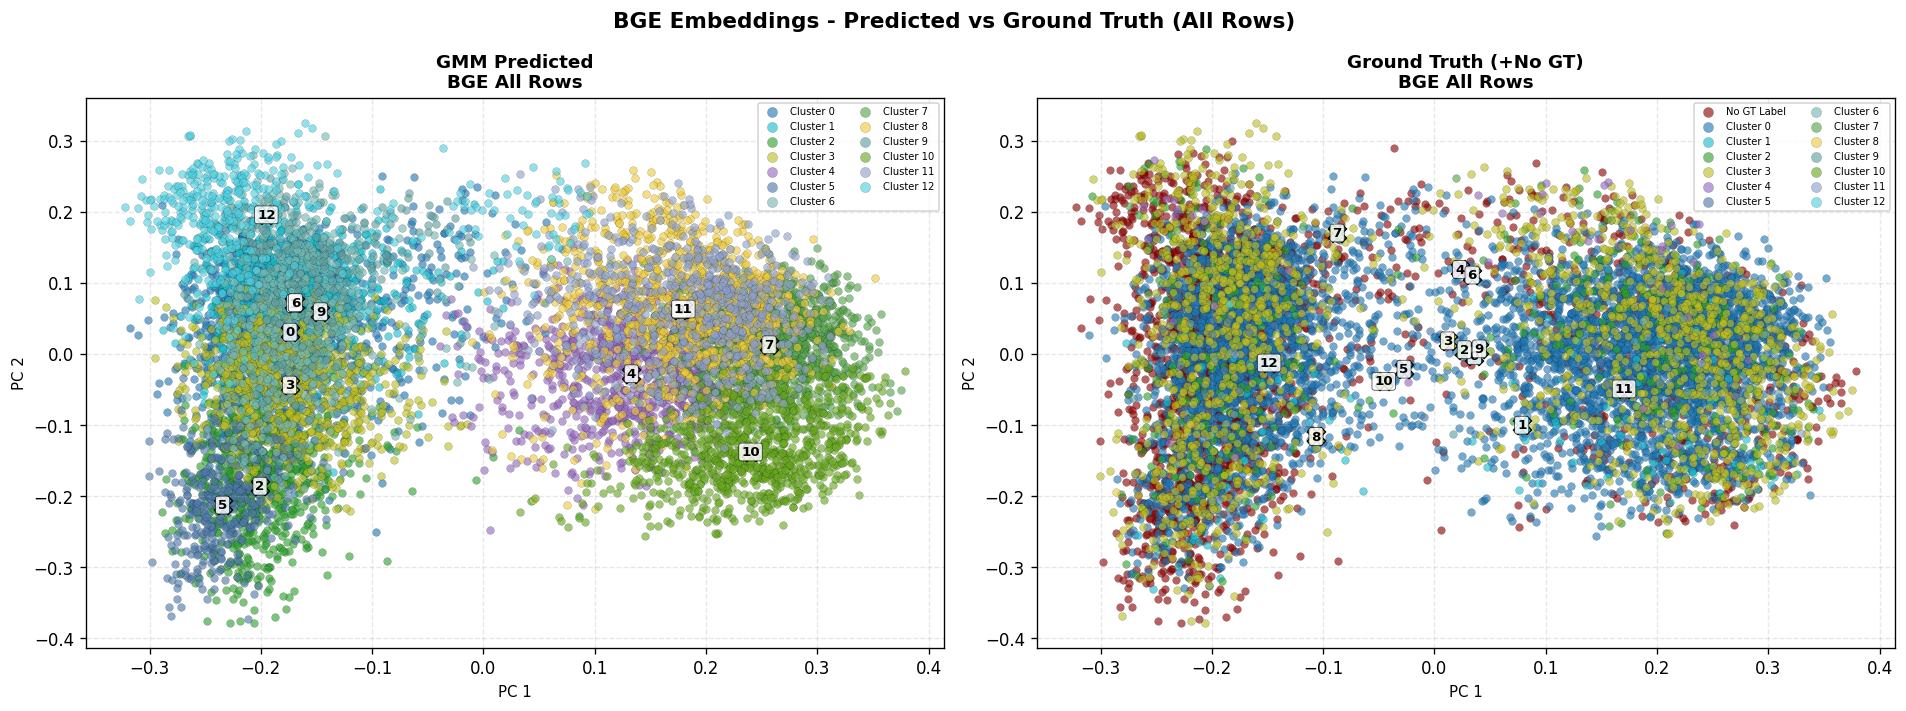

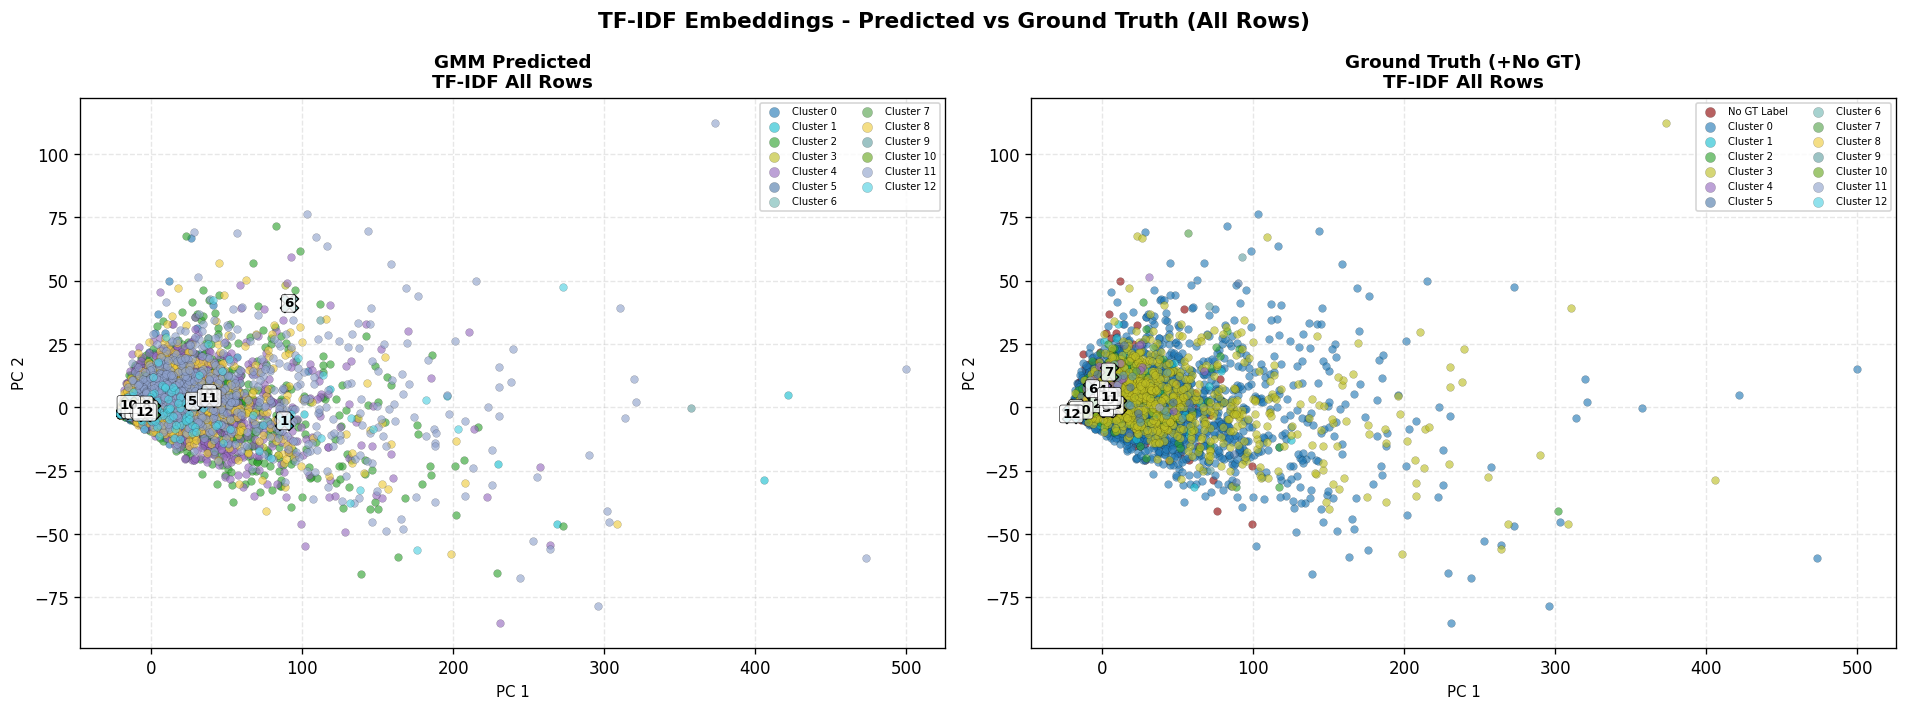

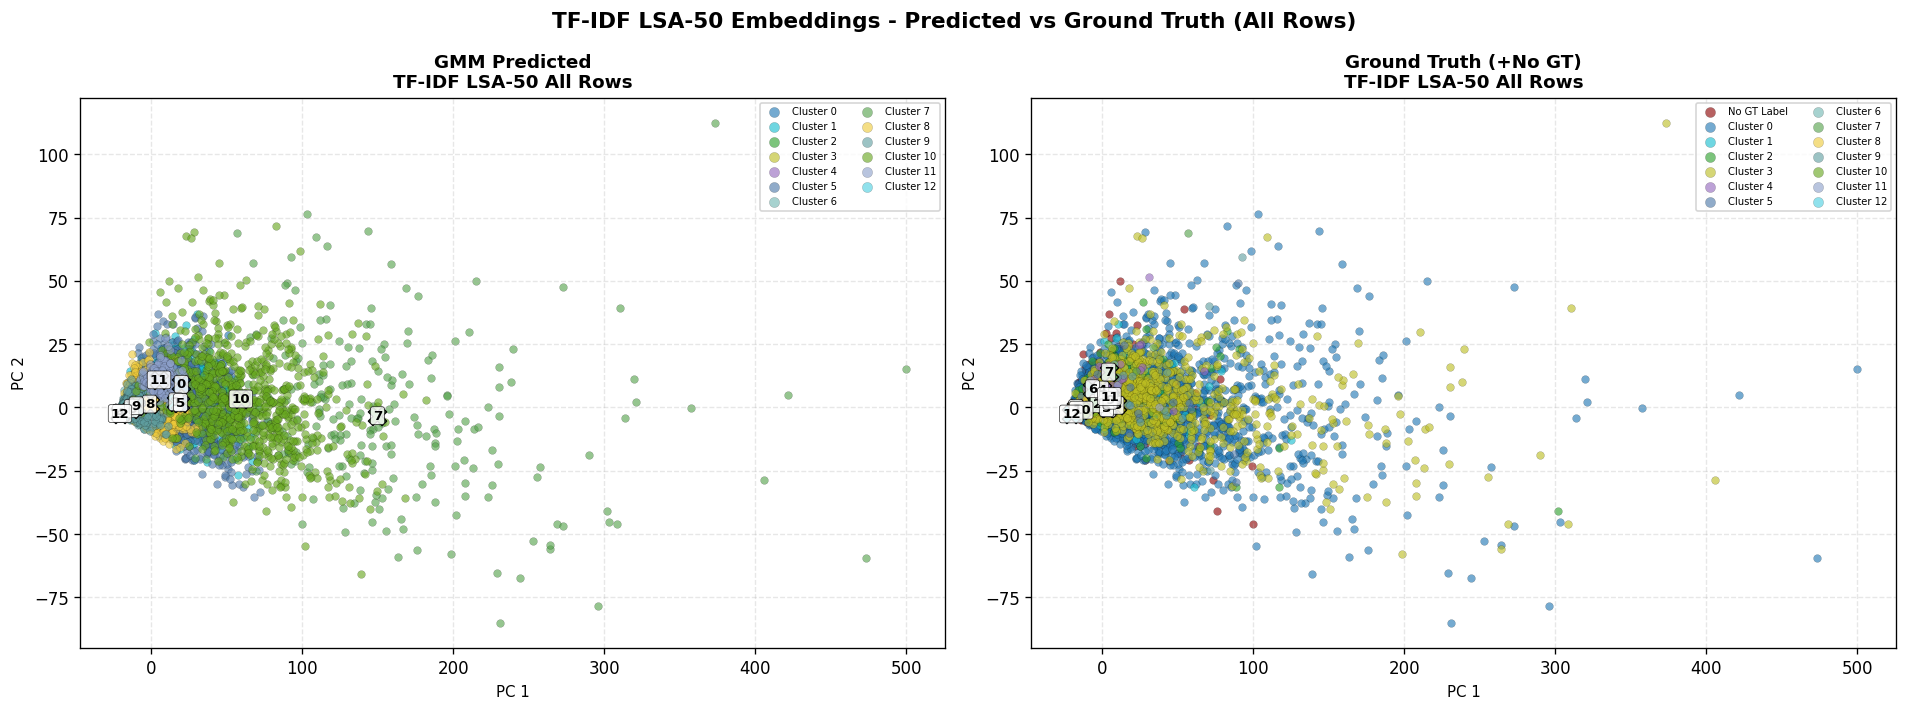

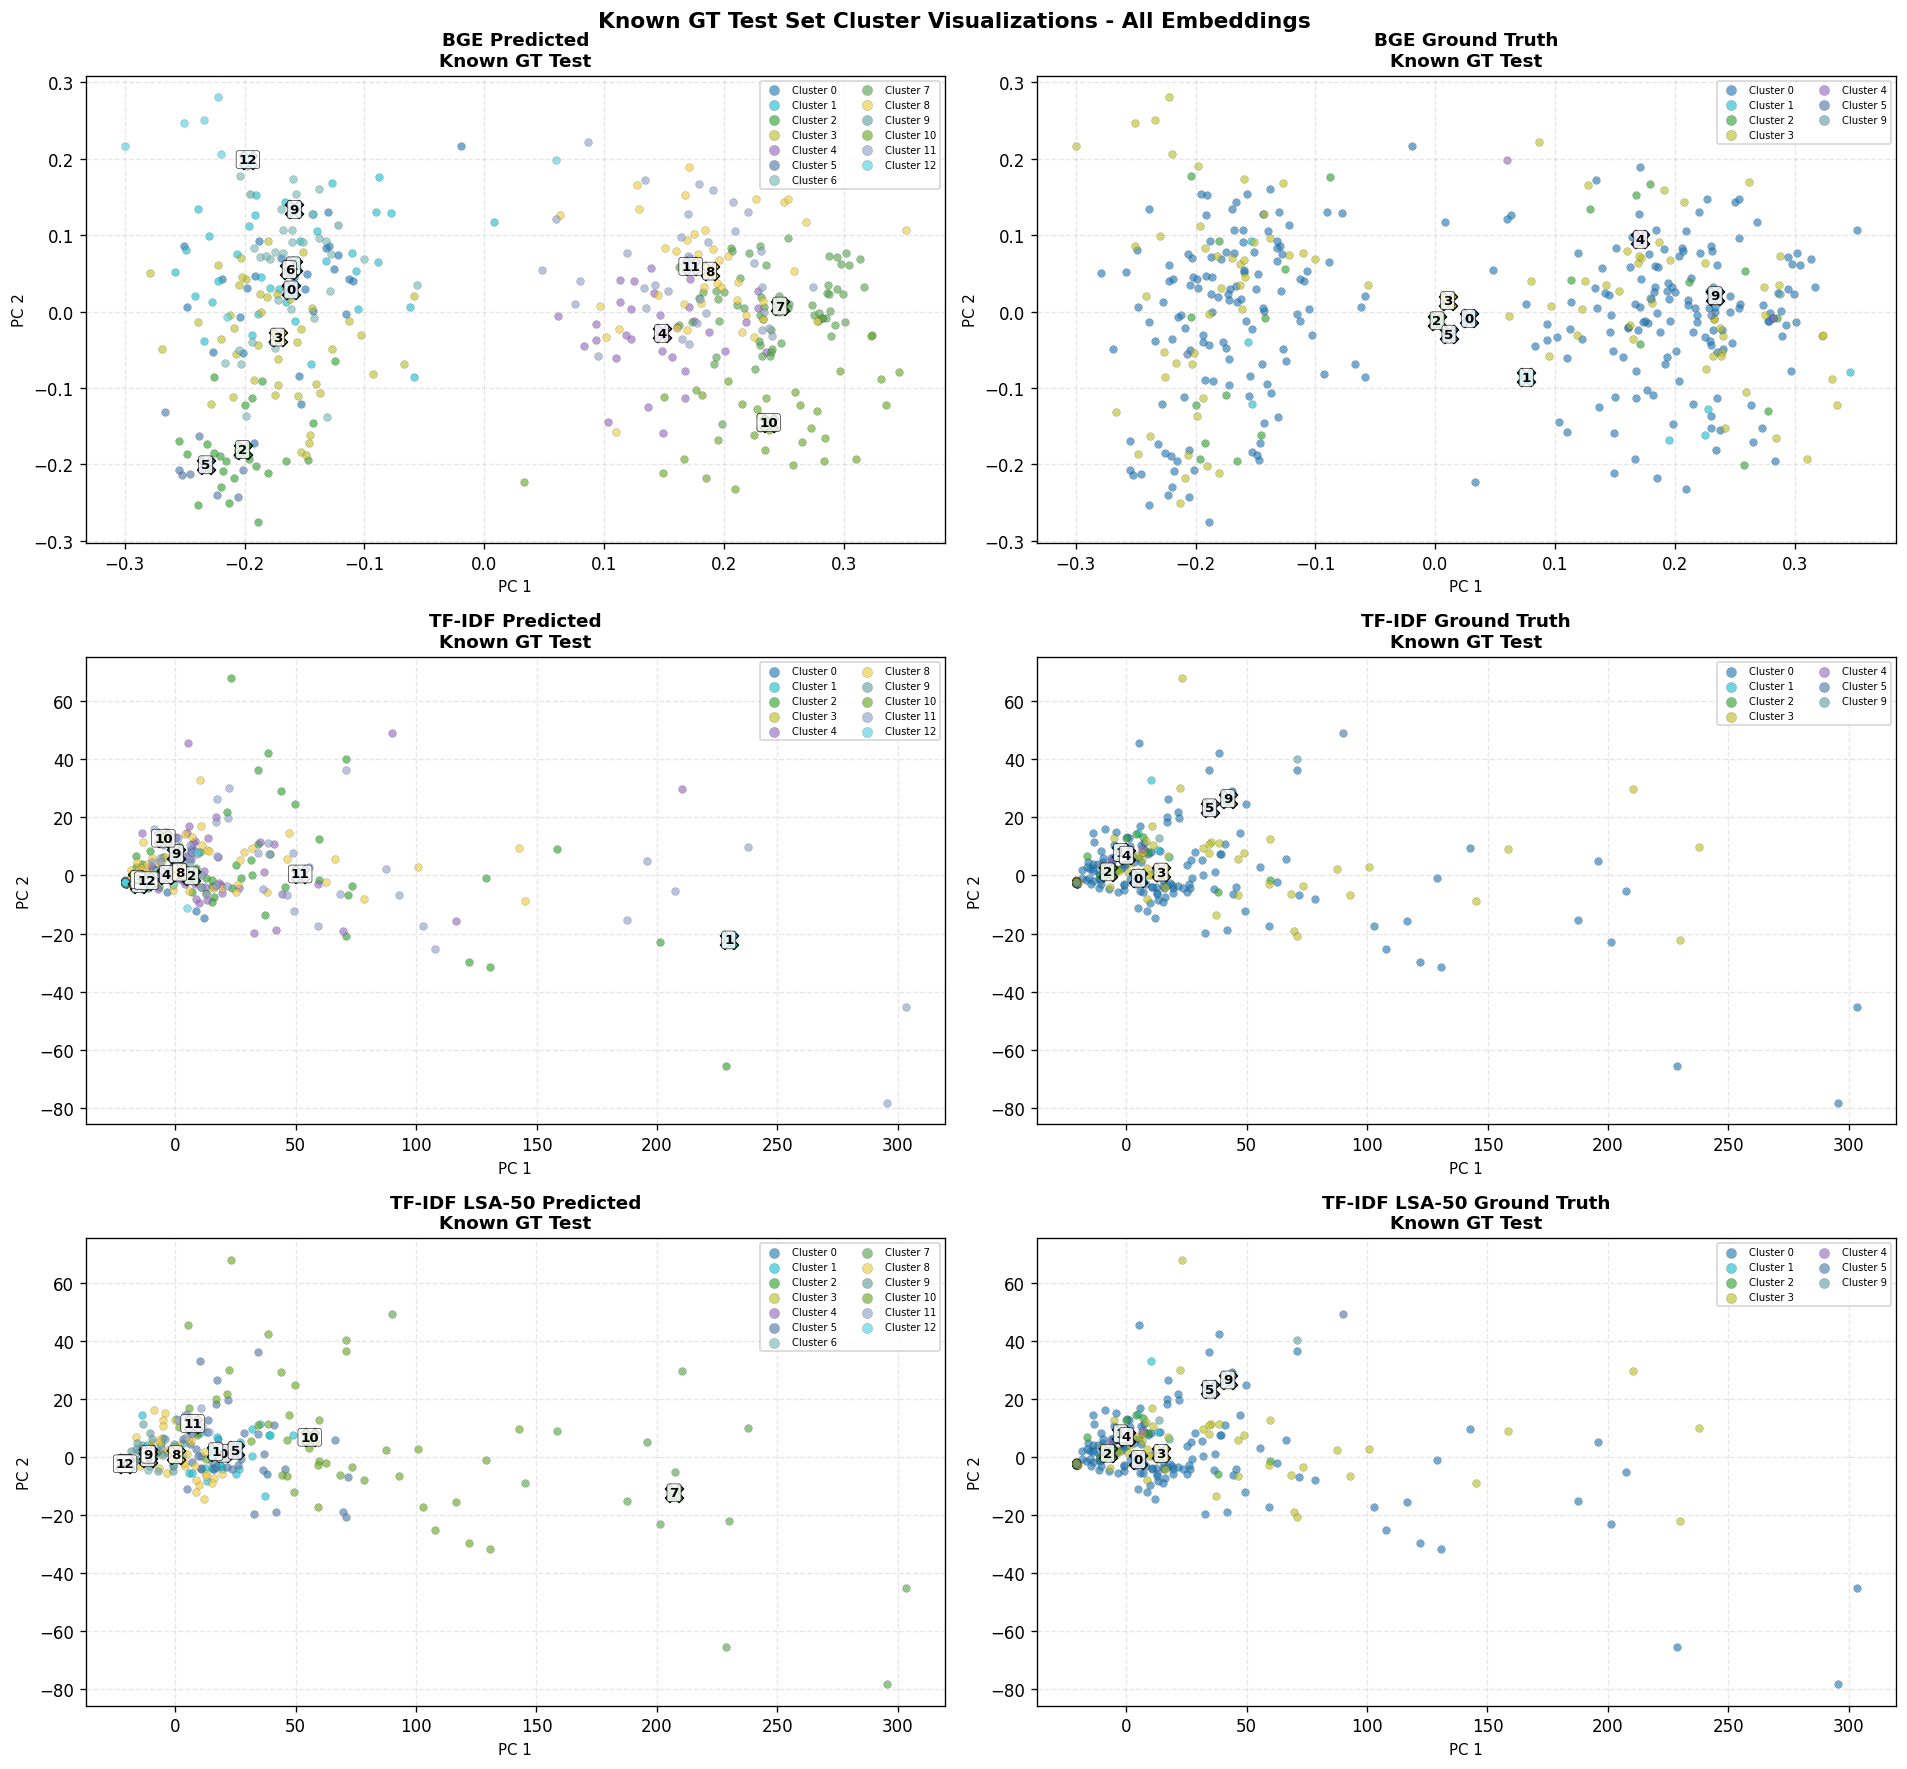

In [11]:
if rank == 0:
    cluster_palette = [
        "#1f77b4", "#17becf", "#2ca02c", "#bcbd22", "#9467bd", "#4c78a8", "#72b7b2",
        "#54a24b", "#eeca3b", "#5f9ea0", "#66a61e", "#8da0cb", "#4dd0e1", "#7cb342",
        "#b3de69", "#80b1d3", "#009688", "#6baed6", "#9ecae1", "#31a354"
    ]
    if N_CLUSTERS > len(cluster_palette):
        repeats = int(np.ceil(N_CLUSTERS / len(cluster_palette)))
        cluster_palette = (cluster_palette * repeats)[:N_CLUSTERS]
    cluster_colors = np.array(cluster_palette[:N_CLUSTERS])

    no_gt_color = "#8B0000"

    def scatter_clusters(ax, X_2d, labels, title, subtitle="", is_ground_truth=False):
        labels = np.asarray(labels)
        unique_labels = np.unique(labels)

        for lbl in unique_labels:
            mask = labels == lbl
            if is_ground_truth and int(lbl) == -1:
                color = no_gt_color
                legend_label = "No GT Label"
            else:
                color = cluster_colors[int(lbl) % N_CLUSTERS]
                legend_label = f"Cluster {int(lbl)}"

            ax.scatter(
                X_2d[mask, 0],
                X_2d[mask, 1],
                s=22,
                alpha=0.62,
                color=color,
                edgecolors="black",
                linewidths=0.12,
                label=legend_label,
            )

            if not (is_ground_truth and int(lbl) == -1):
                cx = float(np.mean(X_2d[mask, 0]))
                cy = float(np.mean(X_2d[mask, 1]))
                ax.scatter(cx, cy, s=120, marker="X", color=color, edgecolors="black", linewidths=0.8, zorder=5)
                ax.text(
                    cx,
                    cy,
                    str(int(lbl)),
                    fontsize=8,
                    fontweight="bold",
                    ha="center",
                    va="center",
                    bbox=dict(boxstyle="round,pad=0.18", fc="white", ec="black", lw=0.4, alpha=0.85),
                    zorder=6,
                )

        ax.set_title(f"{title}\n{subtitle}", fontsize=11, fontweight="bold")
        ax.set_xlabel("PC 1", fontsize=9)
        ax.set_ylabel("PC 2", fontsize=9)
        ax.legend(loc="upper right", fontsize=6, markerscale=1.3, ncol=2)
        ax.grid(True, linestyle="--", alpha=0.3)

    print("Dark red points in ground-truth panels indicate rows with no GT label.")

    viz_file_map = {
        "BGE": "bge_cluster_viz_sequential.png",
        "TF-IDF": "tfidf_cluster_viz_sequential.png",
        "TF-IDF LSA-50": "tfidf_lsa50_cluster_viz_sequential.png",
    }

    for model_name in model_order:
        result = model_results[model_name]
        fig, axes = plt.subplots(1, 2, figsize=(16, 6))
        fig.suptitle(f"{model_name} Embeddings - Predicted vs Ground Truth (All Rows)", fontsize=13, fontweight="bold")
        scatter_clusters(axes[0], result["X2_all"], result["pred_all"], "GMM Predicted", f"{model_name} All Rows")
        scatter_clusters(
            axes[1],
            result["X2_all"],
            result["y_all"],
            "Ground Truth (+No GT)",
            f"{model_name} All Rows",
            is_ground_truth=True,
        )
        plt.tight_layout()
        out_file = MILESTONE2_DIR / viz_file_map.get(model_name, f"{model_name.lower().replace(' ', '_')}_cluster_viz_sequential.png")
        plt.savefig(out_file, bbox_inches="tight")
        plt.show()

    fig, axes = plt.subplots(len(model_order), 2, figsize=(16, 5 * len(model_order)))
    if len(model_order) == 1:
        axes = np.array([axes])

    fig.suptitle("Known GT Test Set Cluster Visualizations - All Embeddings", fontsize=13, fontweight="bold")
    for idx, model_name in enumerate(model_order):
        result = model_results[model_name]
        scatter_clusters(axes[idx][0], result["X2_test"], result["pred_test"], f"{model_name} Predicted", "Known GT Test")
        scatter_clusters(
            axes[idx][1],
            result["X2_test"],
            result["y_test"],
            f"{model_name} Ground Truth",
            "Known GT Test",
            is_ground_truth=True,
        )

    plt.tight_layout()
    plt.savefig(MILESTONE2_DIR / "test_cluster_viz_sequential.png", bbox_inches="tight")
    plt.show()

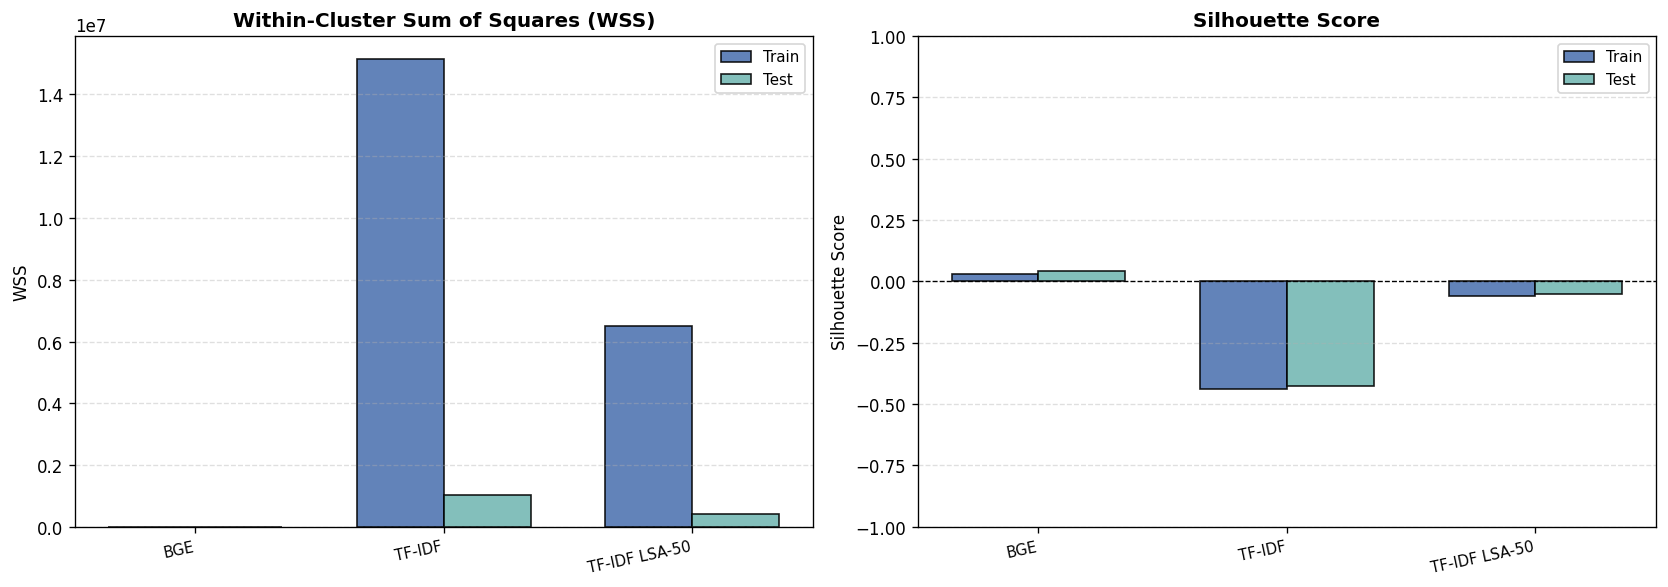

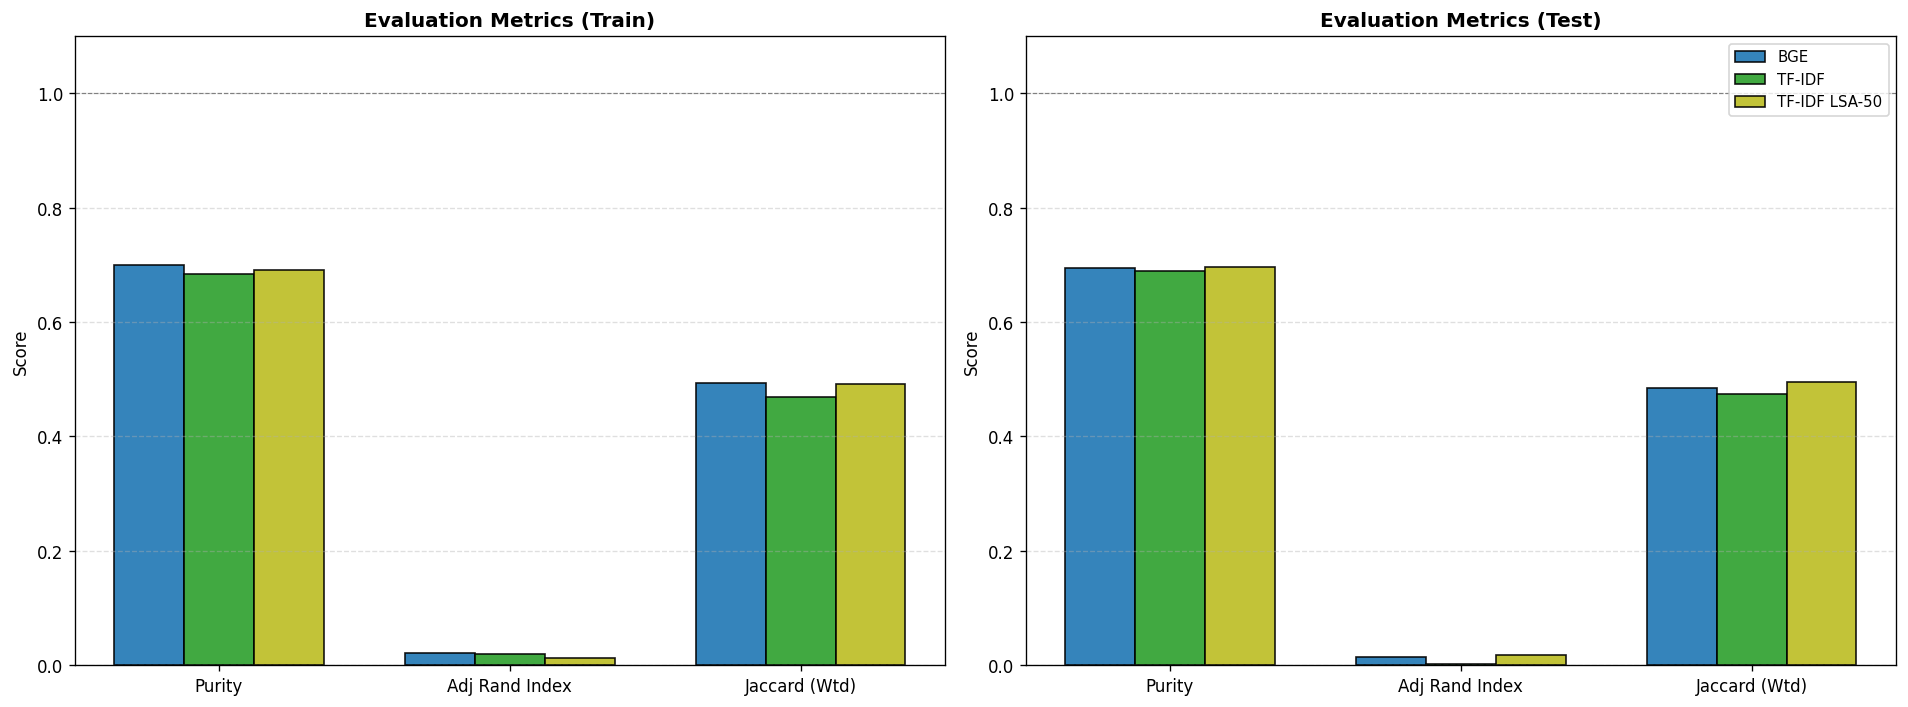

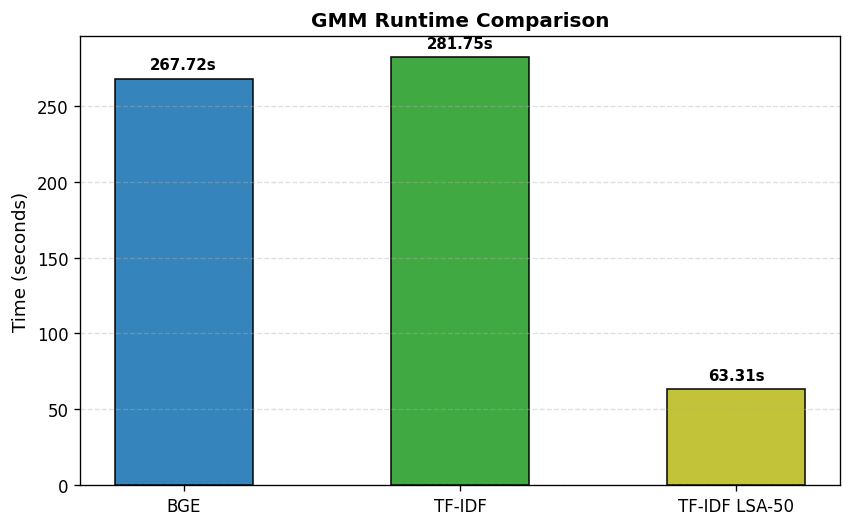

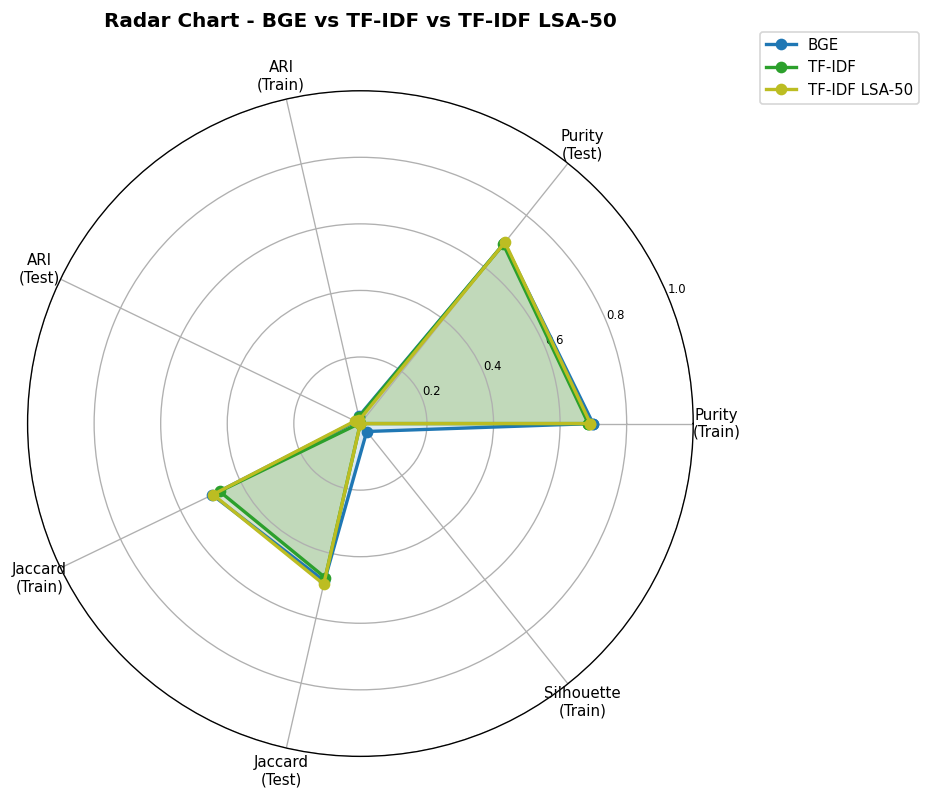

In [12]:
if rank == 0:
    model_colors = {
        "BGE": "#1f77b4",
        "TF-IDF": "#2ca02c",
        "TF-IDF LSA-50": "#bcbd22",
    }

    x = np.arange(len(model_order))
    width = 0.35

    wss_train = [model_results[m]["wss_train"] for m in model_order]
    wss_test = [model_results[m]["wss_test"] for m in model_order]
    sil_train = [model_results[m]["sil_train"] for m in model_order]
    sil_test = [model_results[m]["sil_test"] for m in model_order]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].bar(x - width / 2, wss_train, width, label="Train", color="#4C72B0", edgecolor="black", alpha=0.88)
    axes[0].bar(x + width / 2, wss_test, width, label="Test", color="#72B7B2", edgecolor="black", alpha=0.88)
    axes[0].set_title("Within-Cluster Sum of Squares (WSS)", fontweight="bold")
    axes[0].set_ylabel("WSS")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(model_order, rotation=12, ha="right", fontsize=9)
    axes[0].legend(fontsize=9)
    axes[0].grid(axis="y", linestyle="--", alpha=0.4)

    axes[1].bar(x - width / 2, sil_train, width, label="Train", color="#4C72B0", edgecolor="black", alpha=0.88)
    axes[1].bar(x + width / 2, sil_test, width, label="Test", color="#72B7B2", edgecolor="black", alpha=0.88)
    axes[1].set_title("Silhouette Score", fontweight="bold")
    axes[1].set_ylabel("Silhouette Score")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(model_order, rotation=12, ha="right", fontsize=9)
    axes[1].set_ylim([-1, 1])
    axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[1].legend(fontsize=9)
    axes[1].grid(axis="y", linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.savefig(MILESTONE2_DIR / "wss_silhouette_chart_sequential.png", bbox_inches="tight")
    plt.show()

    metric_keys = [
        ("Purity", "purity"),
        ("Adj Rand Index", "ari"),
        ("Jaccard (Wtd)", "jaccard"),
    ]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for split_idx, split_name in enumerate(["train", "test"]):
        ax = axes[split_idx]
        x_m = np.arange(len(metric_keys))
        w = 0.24
        offsets = np.linspace(-(len(model_order) - 1) / 2, (len(model_order) - 1) / 2, len(model_order)) * w

        for m_idx, model_name in enumerate(model_order):
            vals = [model_results[model_name][f"{key}_{split_name}"] for _, key in metric_keys]
            ax.bar(
                x_m + offsets[m_idx],
                vals,
                w,
                label=model_name,
                color=model_colors.get(model_name, "#1f77b4"),
                edgecolor="black",
                alpha=0.9,
            )

        ax.set_title(f"Evaluation Metrics ({split_name.title()})", fontweight="bold")
        ax.set_xticks(x_m)
        ax.set_xticklabels([m[0] for m in metric_keys], fontsize=10)
        ax.set_ylabel("Score")
        ax.set_ylim([0, 1.1])
        ax.axhline(1, color="grey", linestyle="--", linewidth=0.7)
        ax.grid(axis="y", linestyle="--", alpha=0.4)

    axes[1].legend(loc="upper right", fontsize=9)
    plt.tight_layout()
    plt.savefig(MILESTONE2_DIR / "eval_metrics_chart_sequential.png", bbox_inches="tight")
    plt.show()

    fig, ax = plt.subplots(figsize=(7.2, 4.5))
    runtimes = [model_results[m]["runtime"] for m in model_order]
    colors = [model_colors.get(m, "#1f77b4") for m in model_order]
    bars = ax.bar(model_order, runtimes, color=colors, edgecolor="black", alpha=0.9, width=0.5)
    ax.set_title("GMM Runtime Comparison", fontsize=12, fontweight="bold")
    ax.set_ylabel("Time (seconds)", fontsize=11)
    ax.grid(axis="y", linestyle="--", alpha=0.4)
    for bar in bars:
        h = bar.get_height()
        ax.annotate(
            f"{h:.2f}s",
            xy=(bar.get_x() + bar.get_width() / 2, h),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=9,
            fontweight="bold",
        )
    plt.tight_layout()
    plt.savefig(MILESTONE2_DIR / "runtime_chart_sequential.png", bbox_inches="tight")
    plt.show()

    radar_metrics = [
        ("Purity\n(Train)", "purity_train"),
        ("Purity\n(Test)", "purity_test"),
        ("ARI\n(Train)", "ari_train"),
        ("ARI\n(Test)", "ari_test"),
        ("Jaccard\n(Train)", "jaccard_train"),
        ("Jaccard\n(Test)", "jaccard_test"),
        ("Silhouette\n(Train)", "sil_train"),
    ]

    n = len(radar_metrics)
    angles = np.linspace(0, 2 * np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
    for model_name in model_order:
        vals = [max(0, model_results[model_name][key]) for _, key in radar_metrics]
        vals += vals[:1]
        color = model_colors.get(model_name, "#1f77b4")
        ax.plot(angles, vals, "o-", linewidth=2, color=color, label=model_name)
        ax.fill(angles, vals, alpha=0.15, color=color)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels([m[0] for m in radar_metrics], fontsize=9)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=7)
    ax.set_ylim(0, 1)
    ax.set_title("Radar Chart - BGE vs TF-IDF vs TF-IDF LSA-50", fontsize=12, fontweight="bold", pad=20)
    ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.1), fontsize=9)
    plt.tight_layout()
    plt.savefig(MILESTONE2_DIR / "radar_chart_sequential.png", bbox_inches="tight")
    plt.show()

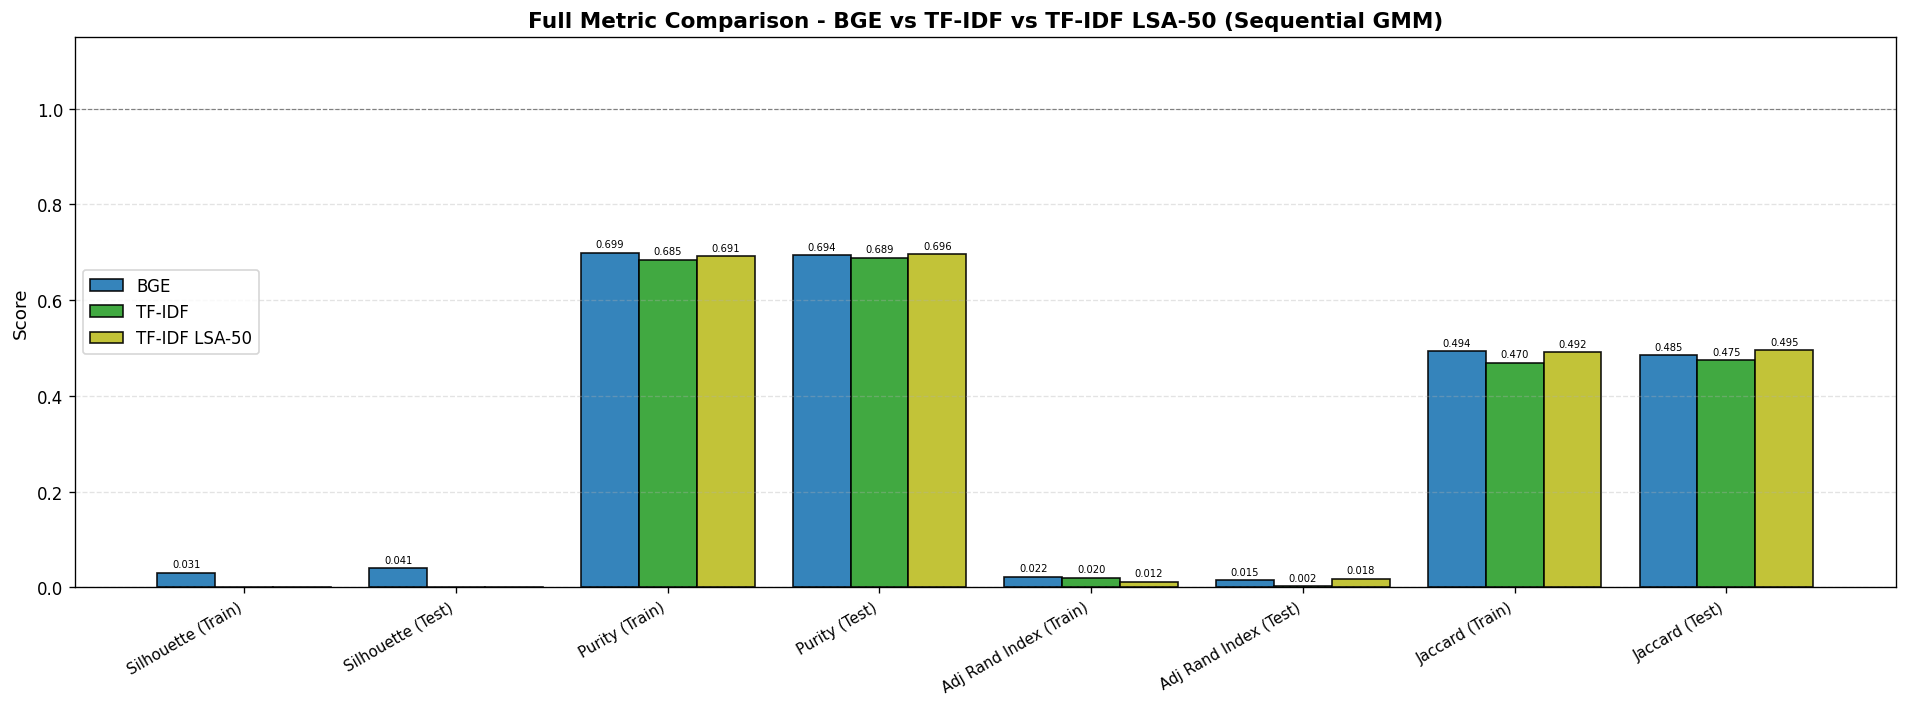

In [13]:
if rank == 0:
    plot_metrics = [
        "Silhouette (Train)",
        "Purity (Train)",
        "Adj Rand Index (Train)",
        "Jaccard (Train)",
        "Silhouette (Test)",
        "Purity (Test)",
        "Adj Rand Index (Test)",
        "Jaccard (Test)",
    ]

    plot_df = comparison_df[comparison_df["Metric"].isin(plot_metrics)].copy()
    x = np.arange(len(plot_df))
    n_models = len(model_order)
    width = 0.82 / max(1, n_models)

    model_colors = {
        "BGE": "#1f77b4",
        "TF-IDF": "#2ca02c",
        "TF-IDF LSA-50": "#bcbd22",
    }

    fig, ax = plt.subplots(figsize=(16, 6))
    for idx, model_name in enumerate(model_order):
        offset = (idx - (n_models - 1) / 2) * width
        bars = ax.bar(
            x + offset,
            plot_df[model_name],
            width,
            label=model_name,
            color=model_colors.get(model_name, "#1f77b4"),
            edgecolor="black",
            alpha=0.9,
        )
        for bar in bars:
            h = bar.get_height()
            ax.annotate(
                f"{h:.3f}",
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 2),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=6,
            )

    ax.set_title("Full Metric Comparison - BGE vs TF-IDF vs TF-IDF LSA-50 (Sequential GMM)", fontsize=13, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["Metric"], rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Score", fontsize=11)
    ax.set_ylim([0, 1.15])
    ax.axhline(1, color="grey", linestyle="--", linewidth=0.7)
    ax.legend(fontsize=10)
    ax.grid(axis="y", linestyle="--", alpha=0.35)

    plt.tight_layout()
    plt.savefig(MILESTONE2_DIR / "comparison_chart_sequential.png", bbox_inches="tight")
    plt.show()

In [14]:
if rank == 0:
    metric_keys = [
        "purity_train",
        "purity_test",
        "ari_train",
        "ari_test",
        "jaccard_train",
        "jaccard_test",
        "sil_train",
        "sil_test",
    ]

    aggregate_scores = {
        model_name: float(np.sum([model_results[model_name][k] for k in metric_keys]))
        for model_name in model_order
    }

    best_model = max(aggregate_scores, key=aggregate_scores.get)

    print("=" * 80)
    print("FINAL MODEL COMPARISON SUMMARY")
    print("=" * 80)
    for model_name in model_order:
        result = model_results[model_name]
        print(
            f"{model_name:>14} -> score={aggregate_scores[model_name]:.4f} | "
            f"runtime={result['runtime']:.4f}s | "
            f"rows(all/known/no_gt)={result['all_rows']}/{result['known_rows']}/{result['unmatched_rows']}"
        )

    print(f"\nBest Model -> {best_model}")
    print("=" * 80)

    value_format = {model_name: "{:.4f}" for model_name in model_order}

    try:
        safe_display(
            comparison_df.style.format(value_format, na_rep="-")
            .set_caption("Full Metric Comparison - All Embeddings (Sequential GMM)")
            .hide(axis="index")
        )
    except Exception:
        print(comparison_df.to_string(index=False))

    model_stage_times["total_pipeline_seconds"] = time.perf_counter() - model_pipeline_start

    print("\nTiming summary (seconds):")
    for stage_name, stage_value in model_stage_times.items():
        print(f"  {stage_name}: {stage_value:.4f}")

comm.Barrier()
if rank == 0:
    print("Sequential model notebook completed.")

FINAL MODEL COMPARISON SUMMARY
           BGE -> score=2.4807 | runtime=267.7229s | rows(all/known/no_gt)=10253/7834/2419
        TF-IDF -> score=1.4765 | runtime=281.7536s | rows(all/known/no_gt)=10253/7834/2419
 TF-IDF LSA-50 -> score=2.2968 | runtime=63.3109s | rows(all/known/no_gt)=10253/7834/2419

Best Model -> BGE


Metric,BGE,TF-IDF,TF-IDF LSA-50,Best
WSS (Train),1163.2174,15136304.2624,6496480.8835,BGE
WSS (Test),59.9067,1045351.5079,407112.7485,BGE
Silhouette (Train),0.0305,-0.4387,-0.0584,BGE
Silhouette (Test),0.0405,-0.4246,-0.0493,BGE
Purity (Train),0.6990,0.6848,0.6913,BGE
Purity (Test),0.6939,0.6888,0.6964,TF-IDF LSA-50
Adj Rand Index (Train),0.0220,0.0198,0.0121,BGE
Adj Rand Index (Test),0.0154,0.0020,0.0179,TF-IDF LSA-50
Jaccard (Train),0.4940,0.4695,0.4916,BGE
Jaccard (Test),0.4854,0.4749,0.4952,TF-IDF LSA-50



Timing summary (seconds):
  data_prep_seconds: 10.6159
  bge_gmm_total_seconds: 268.0697
  bge_gmm_fit_seconds: 267.7229
  tfidf_gmm_total_seconds: 284.7794
  tfidf_gmm_fit_seconds: 281.7536
  tfidf_lsa50_gmm_total_seconds: 63.4352
  tfidf_lsa50_gmm_fit_seconds: 63.3109
  postprocessing_seconds: 0.2233
  total_pipeline_seconds: 655.3249
Sequential model notebook completed.


In [15]:
if rank == 0:
    thread_env = {
        "omp_num_threads": os.environ.get("OMP_NUM_THREADS", ""),
        "openblas_num_threads": os.environ.get("OPENBLAS_NUM_THREADS", ""),
        "mkl_num_threads": os.environ.get("MKL_NUM_THREADS", ""),
        "numexpr_num_threads": os.environ.get("NUMEXPR_NUM_THREADS", ""),
    }

    runtime_rows = []
    for model_name in model_order:
        result = model_results[model_name]
        stage_key = model_stage_key(model_name)
        runtime_rows.append(
            {
                "model": model_name,
                "gmm_fit_seconds": result["runtime"],
                "gmm_total_seconds": model_stage_times.get(f"{stage_key}_gmm_total_seconds", np.nan),
                "n_init": result.get("n_init", np.nan),
                "best_init_run": result.get("best_init_run", np.nan),
                "process_count": int(size),
                "all_rows": result.get("all_rows", np.nan),
                "known_gt_rows": result.get("known_rows", np.nan),
                "unmatched_no_gt_rows": result.get("unmatched_rows", np.nan),
                "gmm_iterations": result.get("n_iter", np.nan),
                **thread_env,
            }
        )

    runtime_baseline_df = pd.DataFrame(runtime_rows)

    runtime_baseline_out = MILESTONE2_DIR / "runtime_baseline_sequential.csv"
    runtime_baseline_df.to_csv(runtime_baseline_out, index=False)
    print(f"Saved sequential runtime baseline to: {runtime_baseline_out}")

Saved sequential runtime baseline to: C:\Users\Dell\Desktop\Semester 6\Parallel & Distributed Computing\Project\Milestone 2\runtime_baseline_sequential.csv


In [16]:
if rank == 0:
    seq_path = MILESTONE2_DIR / "runtime_baseline_sequential.csv"
    par_path = MILESTONE2_DIR / "runtime_baseline_parallel.csv"

    print("\n" + "=" * 72)
    print("SEQUENTIAL VS PARALLEL TIMING COMPARISON")
    print("=" * 72)

    if not seq_path.exists():
        print(f"Sequential baseline file not found: {seq_path}")
    elif not par_path.exists():
        print(f"Parallel baseline file not found: {par_path}")
        print("Run Parallelized_Model.ipynb once to generate runtime_baseline_parallel.csv, then rerun this cell.")
    else:
        seq_df = pd.read_csv(seq_path)
        par_df = pd.read_csv(par_path)

        needed = [
            "model",
            "gmm_fit_seconds",
            "gmm_total_seconds",
            "process_count",
            "all_rows",
            "known_gt_rows",
            "unmatched_no_gt_rows",
            "gmm_iterations",
        ]

        for col in needed:
            if col not in seq_df.columns:
                seq_df[col] = np.nan
            if col not in par_df.columns:
                par_df[col] = np.nan

        comp_df = seq_df[needed].merge(
            par_df[needed],
            on="model",
            how="inner",
            suffixes=("_seq", "_par"),
        )

        if comp_df.empty:
            print("No overlapping model names found in sequential and parallel baseline files.")
        else:
            comp_df["fit_speedup_x"] = np.where(
                comp_df["gmm_fit_seconds_par"] > 0,
                comp_df["gmm_fit_seconds_seq"] / comp_df["gmm_fit_seconds_par"],
                np.nan,
            )
            comp_df["total_speedup_x"] = np.where(
                comp_df["gmm_total_seconds_par"] > 0,
                comp_df["gmm_total_seconds_seq"] / comp_df["gmm_total_seconds_par"],
                np.nan,
            )

            timing_cols = [
                "model",
                "gmm_fit_seconds_seq",
                "gmm_fit_seconds_par",
                "fit_speedup_x",
                "gmm_total_seconds_seq",
                "gmm_total_seconds_par",
                "total_speedup_x",
            ]
            print("\nTiming table (seconds):")
            print(comp_df[timing_cols].to_string(index=False, float_format=lambda v: f"{v:.4f}" if pd.notna(v) else "nan"))

            print("\nRun-condition diagnostics:")
            diag_cols = [
                "model",
                "process_count_seq",
                "process_count_par",
                "all_rows_seq",
                "all_rows_par",
                "known_gt_rows_seq",
                "known_gt_rows_par",
                "unmatched_no_gt_rows_seq",
                "unmatched_no_gt_rows_par",
                "gmm_iterations_seq",
                "gmm_iterations_par",
            ]
            print(comp_df[diag_cols].to_string(index=False, float_format=lambda v: f"{v:.0f}" if pd.notna(v) else "nan"))

            print("\nSpeedup summary:")
            for _, row in comp_df.iterrows():
                fit_seq = row["gmm_fit_seconds_seq"]
                fit_par = row["gmm_fit_seconds_par"]
                fit_spd = row["fit_speedup_x"]
                tot_seq = row["gmm_total_seconds_seq"]
                tot_par = row["gmm_total_seconds_par"]
                tot_spd = row["total_speedup_x"]

                fit_msg = f"fit seq={fit_seq:.4f}s, par={fit_par:.4f}s, speedup={fit_spd:.2f}x" if pd.notna(fit_spd) else "fit speedup unavailable"
                tot_msg = f"total seq={tot_seq:.4f}s, par={tot_par:.4f}s, speedup={tot_spd:.2f}x" if pd.notna(tot_spd) else "total speedup unavailable"
                print(f"  {row['model']}: {fit_msg}; {tot_msg}")

                mismatch_notes = []
                if pd.notna(row["all_rows_seq"]) and pd.notna(row["all_rows_par"]) and row["all_rows_seq"] != row["all_rows_par"]:
                    mismatch_notes.append("all_rows mismatch")
                if pd.notna(row["known_gt_rows_seq"]) and pd.notna(row["known_gt_rows_par"]) and row["known_gt_rows_seq"] != row["known_gt_rows_par"]:
                    mismatch_notes.append("known_gt_rows mismatch")
                if pd.notna(row["unmatched_no_gt_rows_seq"]) and pd.notna(row["unmatched_no_gt_rows_par"]) and row["unmatched_no_gt_rows_seq"] != row["unmatched_no_gt_rows_par"]:
                    mismatch_notes.append("unmatched rows mismatch")

                if mismatch_notes:
                    print(f"    warning: {', '.join(mismatch_notes)}")

            comp_out = MILESTONE2_DIR / "runtime_speedup_comparison.csv"
            comp_df.to_csv(comp_out, index=False)
            print(f"\nSaved timing comparison to: {comp_out}")


SEQUENTIAL VS PARALLEL TIMING COMPARISON

Timing table (seconds):
        model  gmm_fit_seconds_seq  gmm_fit_seconds_par  fit_speedup_x  gmm_total_seconds_seq  gmm_total_seconds_par  total_speedup_x
          BGE             267.7229             156.9750         1.7055               268.0697               157.3418           1.7037
       TF-IDF             281.7536             136.5980         2.0626               284.7794               139.1987           2.0458
TF-IDF LSA-50              63.3109              22.5108         2.8125                63.4352                22.6397           2.8019

Run-condition diagnostics:
        model  process_count_seq  process_count_par  all_rows_seq  all_rows_par  known_gt_rows_seq  known_gt_rows_par  unmatched_no_gt_rows_seq  unmatched_no_gt_rows_par  gmm_iterations_seq  gmm_iterations_par
          BGE                  1                  4         10253         10253               7834               7834                      2419                